## 1. Muestre algunos ejemplos de cada una de las modalidades que tiene.

In [18]:
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import random

def label_from_filename(path: Path) -> int:
    """Extrae la etiqueta desde 'X.Y.png' -> X (independiente de la carpeta m0..m4)."""
    return int(path.stem.split(".")[0])

def sample_images_by_modality(root="PolyMNIST/MMNIST", split="train", k=6, seed=42):
    """
    Devuelve un dict {'m0': [paths...], 'm1': [...], ...} con k ejemplos por modalidad.
    """
    random.seed(seed)
    root = Path(root) / split
    if not root.exists():
        raise FileNotFoundError(f"No encuentro la ruta: {root.resolve()}")

    out = {}
    modalities = sorted([d for d in root.iterdir() if d.is_dir() and d.name.startswith("m")])
    if not modalities:
        raise RuntimeError(f"No se hallaron carpetas m* dentro de {root}")

    for mdir in modalities:
        files = sorted(mdir.glob("*.png"))
        if len(files) == 0:
            out[mdir.name] = []
            continue
        k_eff = min(k, len(files))
        out[mdir.name] = random.sample(files, k_eff)
    return out

def show_examples_grid(samples_dict, cmap="gray"):
    """
    Muestra una fila por modalidad con k imágenes y su etiqueta arriba.
    """
    if not samples_dict:
        print("No hay muestras para mostrar.")
        return

    n_rows = len(samples_dict)
    k = max((len(v) for v in samples_dict.values()), default=0)
    if k == 0:
        print("No hay imágenes para mostrar.")
        return

    fig, axes = plt.subplots(n_rows, k, figsize=(2.2*k, 2.2*n_rows))
    if n_rows == 1:
        axes = np.array([axes])  

    for r, (modality, paths) in enumerate(sorted(samples_dict.items())):
        row_axes = axes[r]
        for c in range(k):
            ax = row_axes[c]
            ax.axis("off")
            if c < len(paths):
                p = paths[c]
                try:
                    img = Image.open(p)
                    arr = np.array(img)
                    if arr.ndim == 2:
                        ax.imshow(arr, cmap=cmap)   
                    else:
                        ax.imshow(arr)             
                    ax.set_title(f"{modality} • label={label_from_filename(p)}", fontsize=9)
                except Exception as e:
                    ax.text(0.5, 0.5, f"Error\n{e}", ha="center", va="center", fontsize=8)

    plt.tight_layout()
    plt.show()


DATA_ROOT = "PolyMNIST/MMNIST"  
SPLIT     = "test"              
K         = 6                   
SEED      = 7                   

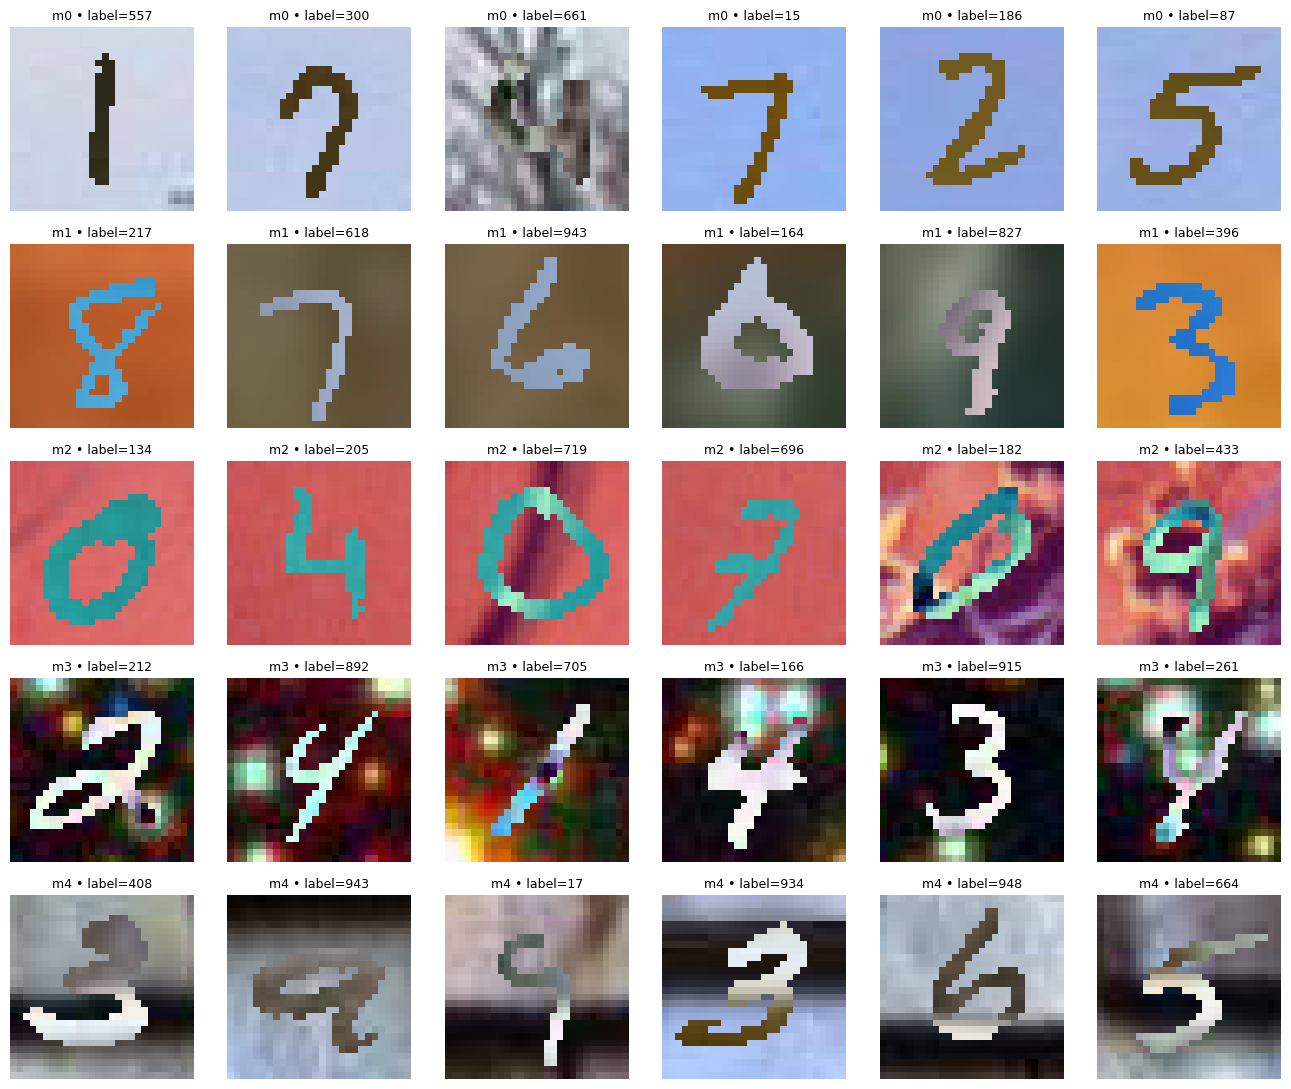

In [19]:
samples = sample_images_by_modality(root=DATA_ROOT, split=SPLIT, k=K, seed=SEED)
show_examples_grid(samples)

## 2. Haga un análisis exploratorio de los datos para entenderlos mejor, documente todos los análisis. Especifique la resolución de las imágenes, la distribución del conjunto de datos, si está balanceado o no, etc.

In [ ]:
import pandas as pd, os, math, re
from concurrent.futures import ThreadPoolExecutor, as_completed

N_JOBS = os.cpu_count() or 1

def true_label_from_path(path):
    """
    Extrae la etiqueta como el ÚLTIMO grupo de dígitos del 'stem' del archivo.
    Ej.: '0.7.png' -> 7, '3.6.png' -> 6, '558.0.png' -> 0
    """
    stem = Path(path).stem
    parts = stem.split(".")
    cand = parts[-1]
    if cand.isdigit():
        return int(cand)

    nums = re.findall(r"\d+", stem)
    if not nums:
        raise ValueError(f"No hay dígitos en el nombre: {stem}")
    return int(nums[-1])

def build_inventory_eda(root_path):
    """
    Recorre PolyMNIST/MMNIST y arma un DataFrame con:
    split (train/test), modality (m0..m4), path, label (0..9) usando true_label_from_path.
    """
    root = Path(root_path)
    rows = []
    for split in ("train", "test"):
        dsplit = root / split
        if not dsplit.exists(): 
            continue
        for mdir in sorted(p for p in dsplit.iterdir() if p.is_dir() and p.name.startswith("m")):
            for p in sorted(mdir.glob("*.png")):
                rows.append({
                    "split": split,
                    "modality": mdir.name,
                    "path": p,
                    "label": true_label_from_path(p),
                })
    return pd.DataFrame(rows)

def quick_meta(path):
    with Image.open(path) as im:
        return im.size[0], im.size[1], im.mode

def balance_report(df: pd.DataFrame, group_cols):
    """
    Reporte de balance por clases para cada grupo en group_cols.
    Métricas: total_imgs, min_per_class, max_per_class, max_min_ratio, coef_var.
    """
    counts = df.groupby(group_cols + ["label"]).size().rename("count").reset_index()
    out = []
    group_iter = [((), counts)] if not group_cols else counts.groupby(group_cols, dropna=False)
    for key, g in group_iter:
        c = g["count"].to_numpy()
        ratio = float(c.max() / c.min()) if c.min() > 0 else float("inf")
        cv = float(np.std(c) / (np.mean(c) + 1e-9))
        row = {}
        if group_cols:
            if isinstance(key, tuple):
                row.update({col: val for col, val in zip(group_cols, key)})
            else:
                row[group_cols[0]] = key
        row.update({
            "total_imgs": int(c.sum()),
            "min_per_class": int(c.min()),
            "max_per_class": int(c.max()),
            "max_min_ratio": ratio,
            "coef_var": cv,
        })
        out.append(row)
    return pd.DataFrame(out)

In [ ]:
ROOT = Path(DATA_ROOT)

inv_df = (
    build_inventory_eda(ROOT)
    .sort_values(["split","modality","path"])
    .reset_index(drop=True)
)

display(inv_df.head(12))

print("\nConteo de etiquetas (esperado 0..9 con recuentos > 0):")
display(inv_df["label"].value_counts().sort_index())

,split,modality,path,label
0,test,m0,PolyMNIST/MMNIST/test/m0/0.0.png,0
1,test,m0,PolyMNIST/MMNIST/test/m0/0.1.png,1
2,test,m0,PolyMNIST/MMNIST/test/m0/0.2.png,2
3,test,m0,PolyMNIST/MMNIST/test/m0/0.3.png,3
4,test,m0,PolyMNIST/MMNIST/test/m0/0.4.png,4
5,test,m0,PolyMNIST/MMNIST/test/m0/0.5.png,5
6,test,m0,PolyMNIST/MMNIST/test/m0/0.6.png,6
7,test,m0,PolyMNIST/MMNIST/test/m0/0.7.png,7
8,test,m0,PolyMNIST/MMNIST/test/m0/0.8.png,8
9,test,m0,PolyMNIST/MMNIST/test/m0/0.9.png,9



Conteo de etiquetas (esperado 0..9 con recuentos > 0):


label
0    34515
1    39385
2    34950
3    35705
4    34120
5    31565
6    34380
7    36465
8    34125
9    34790
Name: count, dtype: int64

In [ ]:
paths = inv_df["path"].tolist()
metas = [None] * len(paths)

with ThreadPoolExecutor(max_workers=N_JOBS) as ex:
    futures = {ex.submit(quick_meta, p): i for i, p in enumerate(paths)}
    for fut in as_completed(futures):
        idx = futures[fut]
        metas[idx] = fut.result()

inv_df["width"]  = [m[0] for m in metas]
inv_df["height"] = [m[1] for m in metas]
inv_df["mode"]   = [m[2] for m in metas]


size_counts = (
    inv_df.assign(size=list(zip(inv_df.width, inv_df.height)))
          .groupby(["split","modality","size"])
          .size().rename("count").reset_index()
          .sort_values(["split","modality","count"], ascending=[True,True,False])
)

mode_counts = (
    inv_df.groupby(["split","modality","mode"]).size()
          .rename("count").reset_index()
          .sort_values(["split","modality","count"], ascending=[True,True,False])
)

display(size_counts.head(20))
display(mode_counts.head(20))

print("Tamaños únicos globales:", inv_df.assign(size=list(zip(inv_df.width, inv_df.height)))["size"].nunique())
print("Modos de imagen (global):")
display(inv_df["mode"].value_counts())

,split,modality,size,count
0,test,m0,"(28, 28)",10000
1,test,m1,"(28, 28)",10000
2,test,m2,"(28, 28)",10000
3,test,m3,"(28, 28)",10000
4,test,m4,"(28, 28)",10000
5,train,m0,"(28, 28)",60000
6,train,m1,"(28, 28)",60000
7,train,m2,"(28, 28)",60000
8,train,m3,"(28, 28)",60000
9,train,m4,"(28, 28)",60000


,split,modality,mode,count
0,test,m0,RGB,10000
1,test,m1,RGB,10000
2,test,m2,RGB,10000
3,test,m3,RGB,10000
4,test,m4,RGB,10000
5,train,m0,RGB,60000
6,train,m1,RGB,60000
7,train,m2,RGB,60000
8,train,m3,RGB,60000
9,train,m4,RGB,60000


Tamaños únicos globales: 1
Modos de imagen (global):


mode
RGB    350000
Name: count, dtype: int64

label
0    34515
1    39385
2    34950
3    35705
4    34120
5    31565
6    34380
7    36465
8    34125
9    34790
Name: count, dtype: int64

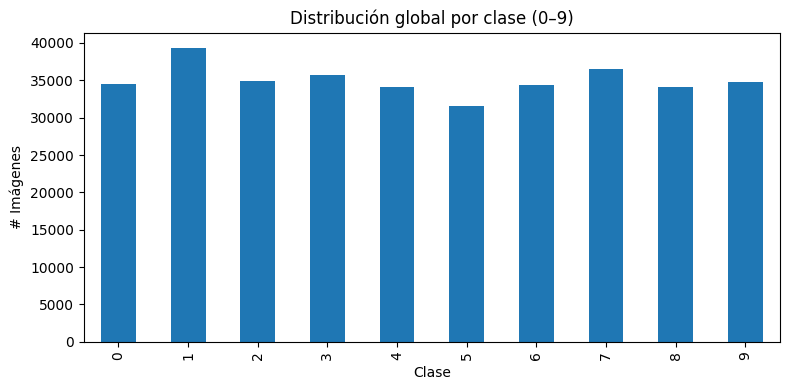

label,0,1,2,3,4,5,6,7,8,9
split,,,,,,,,,,
test,4900,5675,5160,5050,4910,4460,4790,5140,4870,5045
train,29615,33710,29790,30655,29210,27105,29590,31325,29255,29745


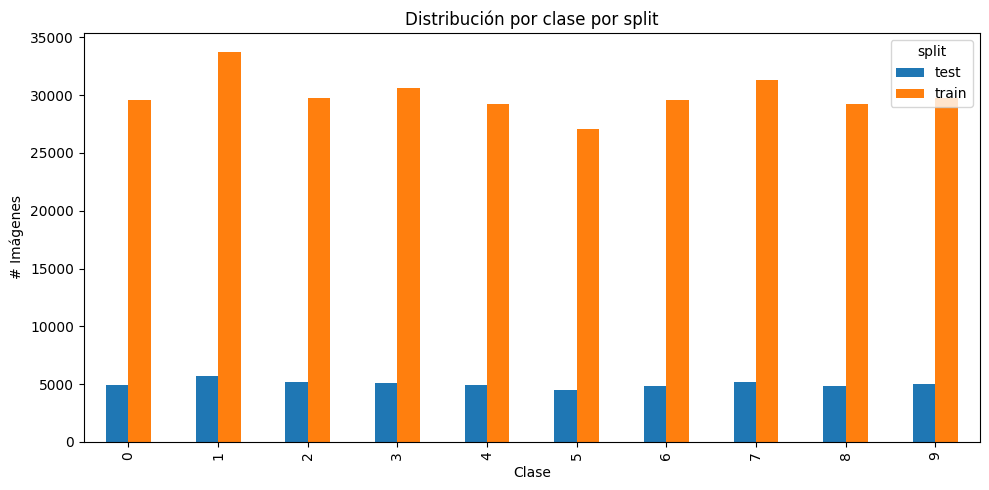

label,0,1,2,3,4,5,6,7,8,9
modality,,,,,,,,,,
m0,6903,7877,6990,7141,6824,6313,6876,7293,6825,6958
m1,6903,7877,6990,7141,6824,6313,6876,7293,6825,6958
m2,6903,7877,6990,7141,6824,6313,6876,7293,6825,6958
m3,6903,7877,6990,7141,6824,6313,6876,7293,6825,6958
m4,6903,7877,6990,7141,6824,6313,6876,7293,6825,6958


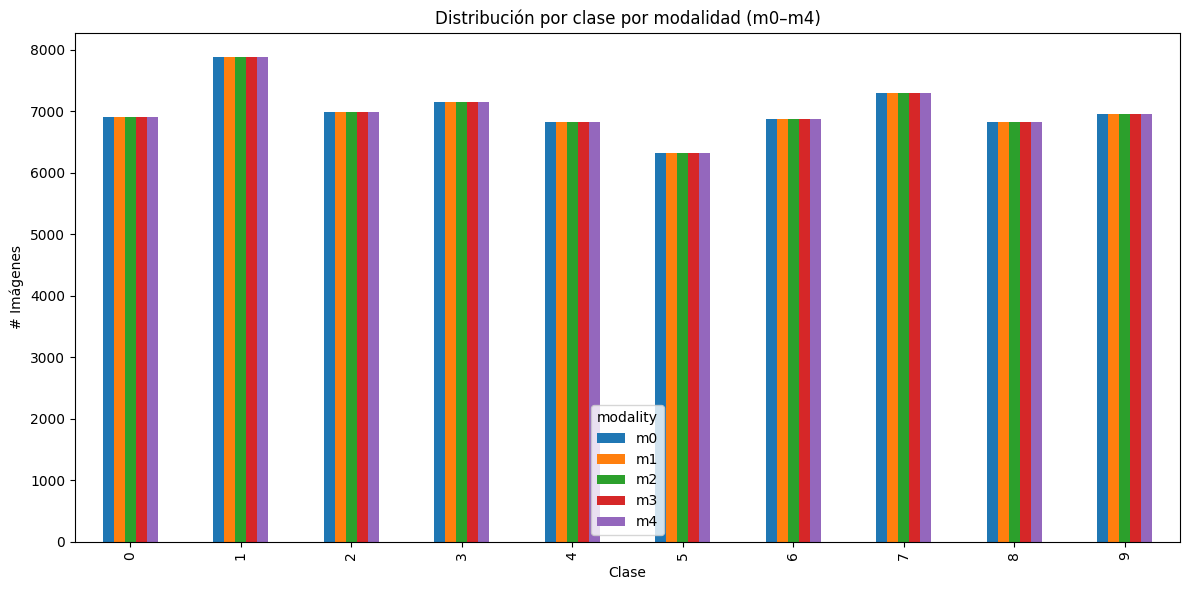

== Balance global ==


,total_imgs,min_per_class,max_per_class,max_min_ratio,coef_var
0,350000,31565,39385,1.247743,0.054118


== Balance por split ==


,split,total_imgs,min_per_class,max_per_class,max_min_ratio,coef_var
0,test,50000,4460,5675,1.272422,0.059196
1,train,300000,27105,33710,1.243682,0.053680


== Balance por modalidad ==


,modality,total_imgs,min_per_class,max_per_class,max_min_ratio,coef_var
0,m0,70000,6313,7877,1.247743,0.054118
1,m1,70000,6313,7877,1.247743,0.054118
2,m2,70000,6313,7877,1.247743,0.054118
3,m3,70000,6313,7877,1.247743,0.054118
4,m4,70000,6313,7877,1.247743,0.054118


In [24]:
# 1) Distribución global por clase
global_counts = inv_df["label"].value_counts().sort_index()
display(global_counts)

plt.figure(figsize=(8,4))
global_counts.plot(kind="bar")
plt.title("Distribución global por clase (0–9)")
plt.xlabel("Clase")
plt.ylabel("# Imágenes")
plt.tight_layout()
plt.show()

# 2) Distribución por split
split_counts = inv_df.groupby(["split","label"]).size().unstack(fill_value=0).sort_index()
display(split_counts)

split_counts.T.plot(kind="bar", figsize=(10,5))
plt.title("Distribución por clase por split")
plt.xlabel("Clase")
plt.ylabel("# Imágenes")
plt.legend(title="split")
plt.tight_layout()
plt.show()

# 3) Distribución por modalidad
mod_counts = inv_df.groupby(["modality","label"]).size().unstack(fill_value=0).sort_index()
display(mod_counts)

mod_counts.T.plot(kind="bar", figsize=(12,6))
plt.title("Distribución por clase por modalidad (m0–m4)")
plt.xlabel("Clase")
plt.ylabel("# Imágenes")
plt.legend(title="modality")
plt.tight_layout()
plt.show()

# 4) Reportes de balance
balance_global   = balance_report(inv_df, [])
balance_by_split = balance_report(inv_df, ["split"])
balance_by_mod   = balance_report(inv_df, ["modality"])

print("== Balance global ==")
display(balance_global)

print("== Balance por split ==")
display(balance_by_split)

print("== Balance por modalidad ==")
display(balance_by_mod)

modality
m0    1
m1    1
m2    1
m3    1
m4    1
Name: size, dtype: int64

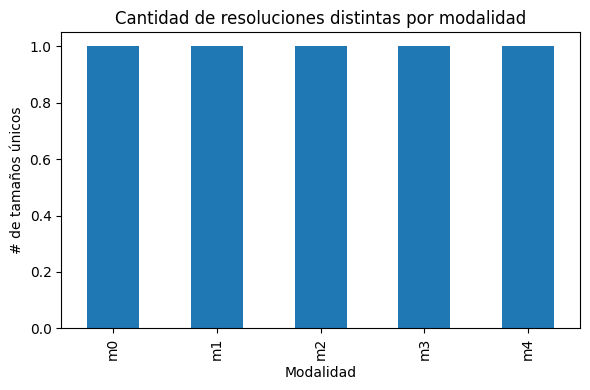

In [ ]:
res_per_mod = (
    inv_df.assign(size=list(zip(inv_df.width, inv_df.height)))
          .groupby("modality")["size"].nunique()
          .sort_values()
)
display(res_per_mod)

plt.figure(figsize=(6,4))
res_per_mod.plot(kind="bar")
plt.title("Cantidad de resoluciones distintas por modalidad")
plt.xlabel("Modalidad")
plt.ylabel("# de tamaños únicos")
plt.tight_layout()
plt.show()

# EDA — PolyMNIST (MMNIST)

---

## 1) Estructura general

- **Total de imágenes:** **350,000**  
  - **train:** 300,000  
  - **test:** 50,000
- **Modalidades:** `m0, m1, m2, m3, m4` (70,000 imágenes cada una).
- **Carpetas:** `PolyMNIST/MMNIST/{train|test}/m{0..4}/*.png`.

> **Regla de etiquetado:** la etiqueta del dígito es **el número después del último punto** en el nombre del archivo (p. ej., `0.7.png → 7`, `3.6.png → 6`).  
> En la primera versión del paso 1 se leyó lo **anterior** al punto, de ahí salían títulos como “label=557” (de `558.0.png`). Corregido, la distribución es coherente (0–9).

---

## 2) Resolución y modo de color

- **Resolución:** todas las imágenes son **28×28**.  
- **Modo:** todas las imágenes son **RGB**.

**Evidencia (por split y modalidad):**

| split | modality | size    | count  |
|:-----:|:--------:|:-------:|------:|
| test  | m0–m4    | (28,28) | 10,000 cada una |
| train | m0–m4    | (28,28) | 60,000 cada una |

| split | modality | mode | count  |
|:-----:|:--------:|:----:|------:|
| test  | m0–m4    | RGB  | 10,000 cada una |
| train | m0–m4    | RGB  | 60,000 cada una |

- **Tamaños únicos globales:** 1  
- **Modos globales:** `RGB = 350,000/350,000`

**Implicación:** no hace falta redimensionar; conviene **normalizar por canal**. Mantener RGB preserva información cromática del fondo (útil para robustez a modalidades).

---

## 3) Distribución por clase (global)

| Clase |   0 |   1 |   2 |   3 |   4 |   5 |   6 |   7 |   8 |   9 |
|-----:|----:|----:|----:|----:|----:|----:|----:|----:|----:|----:|
| #    | 34,515 | **39,385** | 34,950 | 35,705 | 34,120 | **31,565** | 34,380 | 36,465 | 34,125 | 34,790 |

- **Máx.:** clase **1** (39,385)  
- **Mín.:** clase **5** (31,565)  
- **Desbalance relativo:** `max/min ≈ 1.2477` (**+24.8%**)  
- **Coef. de variación (CV):** ~**5.4%**

**Implicación:** desbalance **moderado**. Para no favorecer clases más frecuentes:
- usar **class weights** en la pérdida;
- reportar **macro-F1** o **balanced accuracy**;
- opcional: **WeightedRandomSampler** o aumentación focalizada en clases menos frecuentes (p. ej., “5”).

**Figura 1 — Ejemplos por modalidad**  
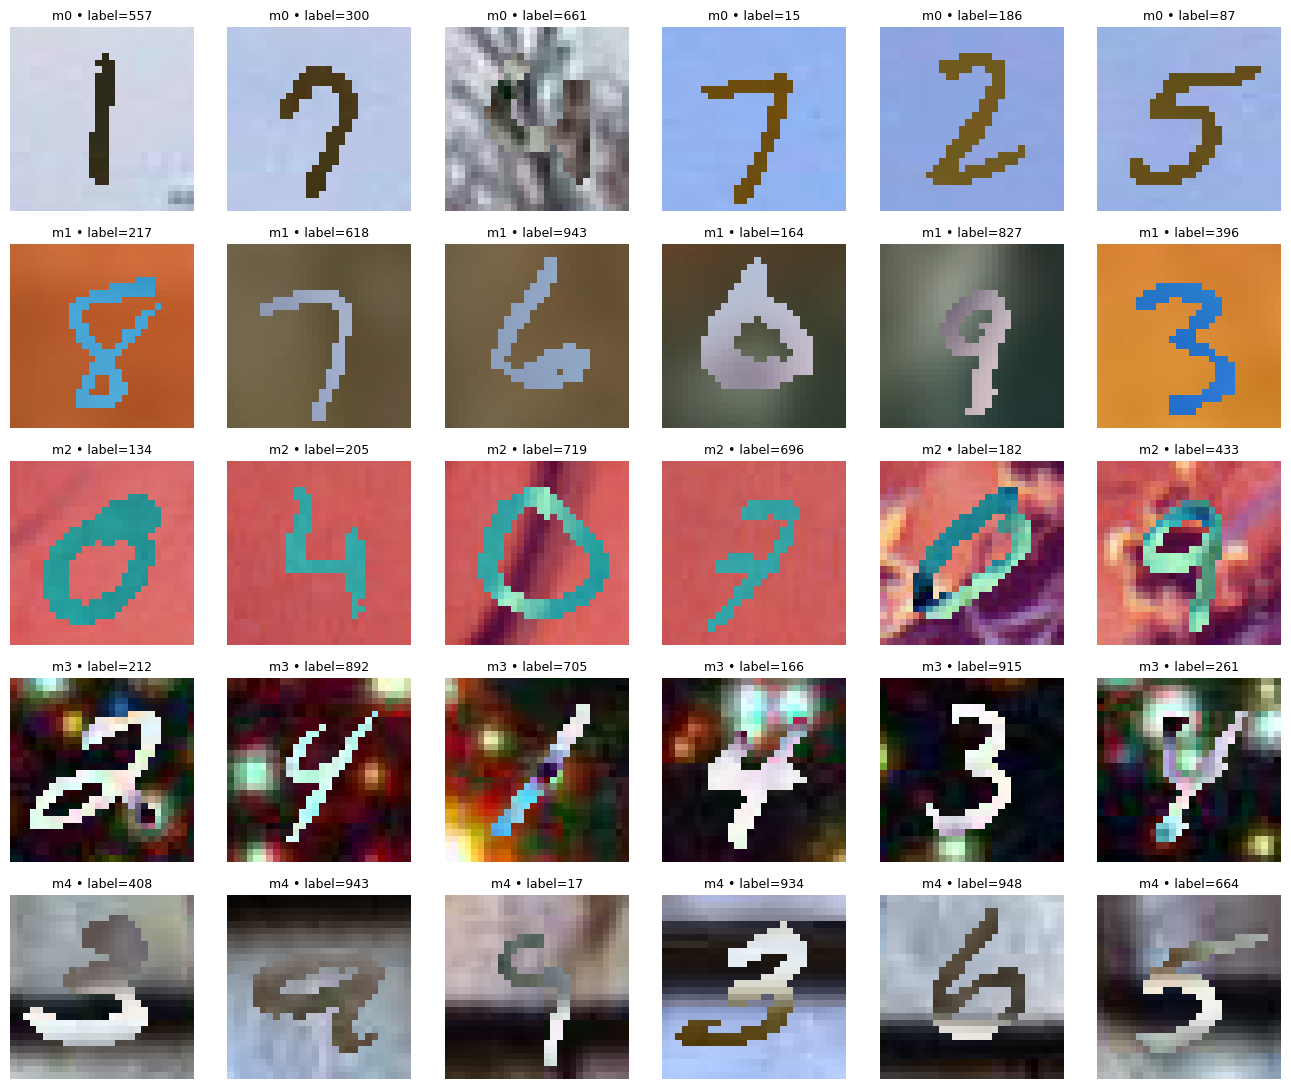

**Figura 2 — Distribución global por clase (0–9)**  
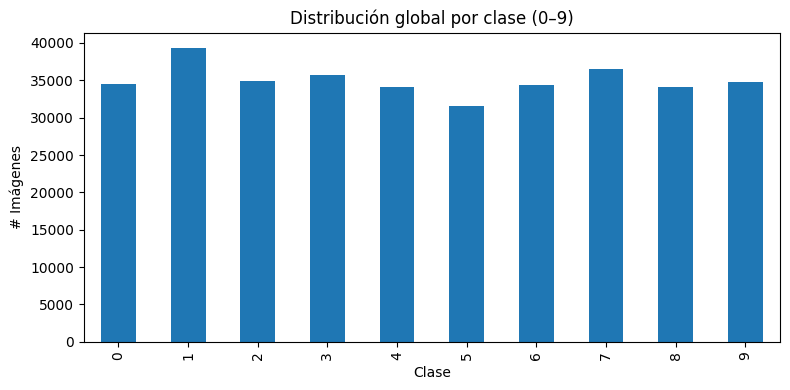

---

## 4) Distribución por split

**Recuentos por clase y split:**

| split |   0 |   1 |   2 |   3 |   4 |   5 |   6 |   7 |   8 |   9 |
|:-----:|----:|----:|----:|----:|----:|----:|----:|----:|----:|----:|
| test  | 4,900 | 5,675 | 5,160 | 5,050 | 4,910 | 4,460 | 4,790 | 5,140 | 4,870 | 5,045 |
| train | 29,615 | 33,710 | 29,790 | 30,655 | 29,210 | 27,105 | 29,590 | 31,325 | 29,255 | 29,745 |

- **Balance (test):** `max/min ≈ 1.2724`, **CV ≈ 5.92%**  
- **Balance (train):** `max/min ≈ 1.2437`, **CV ≈ 5.37%**

**Conclusión:** train y test están **estratificados de forma coherente**, por lo que las métricas en test son representativas.

**Figura 3 — Distribución por clase por split**  
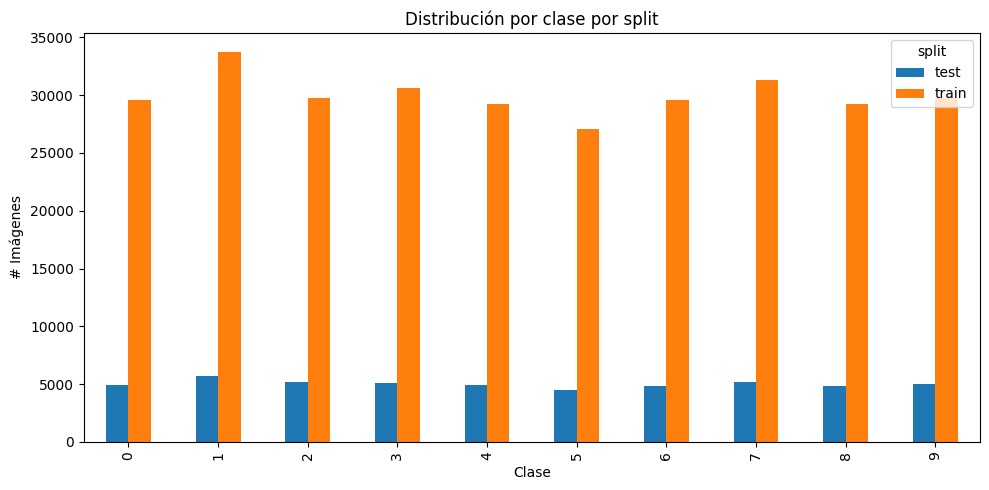

---

## 5) Distribución por modalidad

Los recuentos por clase son **idénticos** en todas las modalidades. (Ejemplo para `m0`; se replica en `m1–m4`):

| modalidad = m0 |   0 |   1 |   2 |   3 |   4 |   5 |   6 |   7 |   8 |   9 |
|:--------------:|----:|----:|----:|----:|----:|----:|----:|----:|----:|----:|
| #              | 6,903 | 7,877 | 6,990 | 7,141 | 6,824 | 6,313 | 6,876 | 7,293 | 6,825 | 6,958 |

**Métricas por modalidad (todas iguales):**

| modalidad | total_imgs | min_per_class | max_per_class | max/min | CV |
|:---------:|-----------:|--------------:|--------------:|--------:|---:|
| m0–m4     | 70,000     | 6,313         | 7,877         | 1.2477  | 0.0541 |

**Conclusión:** las diferencias entre modalidades provienen del **fondo/estilo** (no de la frecuencia de dígitos).

**Figura 4 — Distribución por clase por modalidad**  
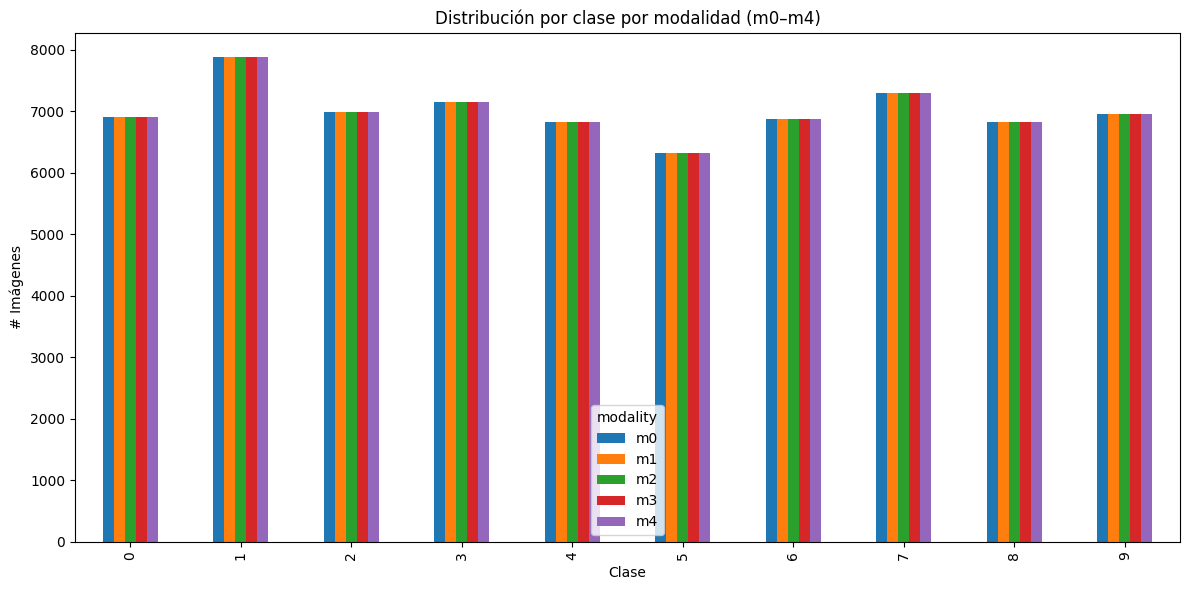

---

## 6) Variabilidad de resolución entre modalidades

Cada modalidad tiene **exactamente 1 tamaño** (28×28).  
**Figura 5 — Cantidad de resoluciones distintas por modalidad**  
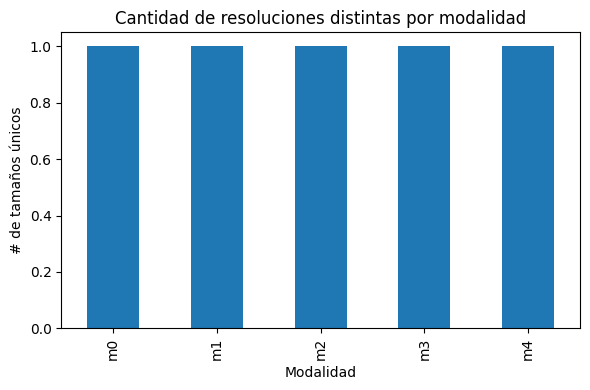

---


## 3. Haga al menos 2 modelos de Deep learning, determine la efectividad de cada uno y seleccione el mejor de ellos.

In [ ]:
import os, time, math, json
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

DEVICE = "mps" if torch.backends.mps.is_available() else ("cuda" if torch.cuda.is_available() else "cpu")
NUM_WORKERS = max(1, (os.cpu_count() or 2) - 1) 
BATCH_SIZE  = 512
EPOCHS      = 5  

print(f"Device: {DEVICE} | num_workers: {NUM_WORKERS} | batch_size: {BATCH_SIZE} | epochs: {EPOCHS}")
os.makedirs("modelos", exist_ok=True)



Device: mps | num_workers: 7 | batch_size: 512 | epochs: 5


In [28]:
class PolyMNISTDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self): 
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row.path).convert("RGB")  
        if self.transform: 
            img = self.transform(img)
        label = int(row.label)
        return img, label

import torch.multiprocessing as mp
try:
    mp.set_start_method("spawn", force=True)  # explícito
except RuntimeError:
    pass

# 1) Re-definir compute_mean_std para usar num_workers=0
def compute_mean_std(df, sample_n=100000, batch_size=2048):
    from torch.utils.data import DataLoader
    ds = PolyMNISTDataset(
        df.sample(sample_n, random_state=42) if len(df) > sample_n else df,
        transform=transforms.ToTensor()
    )
    dl = DataLoader(ds, batch_size=batch_size, shuffle=False,
                    num_workers=0, persistent_workers=False)  # <-- clave
    n = 0
    mean = torch.zeros(3)
    M2   = torch.zeros(3)
    for x, _ in dl:
        x = x.view(x.size(0), 3, -1)
        batch_mean = x.mean(dim=(0,2))
        batch_var  = x.var (dim=(0,2), unbiased=False)
        m = x.size(0)*x.size(2)
        delta = batch_mean - mean
        tot = n + m
        mean = mean + delta * (m / max(tot,1))
        M2   = M2 + batch_var*m + (delta**2) * (n*m/max(tot,1))
        n = tot
    std = torch.sqrt(M2 / max(n,1))
    return mean.tolist(), std.tolist()

# 2) Forzar DataLoader sin workers al crear dl_train/dl_test más adelante
NUM_WORKERS = 0 

train_df = inv_df[inv_df.split=="train"].copy()
test_df  = inv_df[inv_df.split=="test"].copy()

mean_rgb, std_rgb = compute_mean_std(train_df, sample_n=120000)  
print("mean RGB:", mean_rgb, "| std RGB:", std_rgb)

train_tfms = transforms.Compose([
    transforms.RandomAffine(degrees=10, translate=(0.05,0.05)),  
    transforms.ToTensor(),
    transforms.Normalize(mean_rgb, std_rgb),
])
test_tfms = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean_rgb, std_rgb),
])

ds_train = PolyMNISTDataset(train_df, transform=train_tfms)
ds_test  = PolyMNISTDataset(test_df,  transform=test_tfms)

dl_train = DataLoader(ds_train, batch_size=BATCH_SIZE, shuffle=True,  num_workers=NUM_WORKERS, persistent_workers=NUM_WORKERS>0)
dl_test  = DataLoader(ds_test,  batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, persistent_workers=NUM_WORKERS>0)

mean RGB: [0.4812776446342468, 0.41404989361763, 0.41118964552879333] | std RGB: [0.28851112723350525, 0.2750401496887207, 0.2976503372192383]


In [ ]:
class CNN_Lite(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 5, padding=2), nn.ReLU(inplace=True),
            nn.MaxPool2d(2),                 # 28 -> 14
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(inplace=True),
            nn.MaxPool2d(2),                 # 14 -> 7
        )
        self.head = nn.Sequential(
            nn.AdaptiveAvgPool2d((1,1)),    # 64x7x7 -> 64x1x1
            nn.Flatten(),                    # 64
            nn.Linear(64, 128), nn.ReLU(inplace=True),
            nn.Dropout(0.2),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        return self.head(x)

# === Modelo 2: CNN más profunda con BN + Dropout ===
class CNN_Deep(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        def block(cin, cout):
            return nn.Sequential(
                nn.Conv2d(cin, cout, 3, padding=1, bias=False),
                nn.BatchNorm2d(cout),
                nn.ReLU(inplace=True)
            )
        self.features = nn.Sequential(
            block(3, 32), block(32, 32), nn.MaxPool2d(2),      # 28->14
            block(32, 64), block(64, 64), nn.MaxPool2d(2),     # 14->7
            block(64,128),                                     # 7->7
        )
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d((1,1)), nn.Flatten(),
            nn.Dropout(0.3),
            nn.Linear(128, 128), nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)
    

def train_one(model, dl_train, dl_val, epochs=EPOCHS, lr=1e-3, wd=1e-4, name="model"):
    model = model.to(DEVICE)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=wd)
    best_acc, best_state = 0.0, None
    history = []

    for ep in range(1, epochs+1):
        t0 = time.time()
        model.train()
        running = 0.0
        total, correct = 0, 0
        for x, y in dl_train:
            x, y = x.to(DEVICE), torch.as_tensor(y, device=DEVICE)
            optimizer.zero_grad(set_to_none=True)
            logits = model(x)
            loss = criterion(logits, y)
            loss.backward()
            optimizer.step()

            running += loss.item() * x.size(0)
            preds = logits.argmax(1)
            total += y.size(0)
            correct += (preds == y).sum().item()

        train_loss = running / max(total,1)
        train_acc  = correct / max(total,1)

        # validación (en test, por simplicidad de la práctica)
        val_acc, val_loss = evaluate(model, dl_val, criterion)
        history.append({"epoch": ep, "train_loss": train_loss, "train_acc": train_acc,
                        "val_loss": val_loss, "val_acc": val_acc, "secs": time.time()-t0})
        if val_acc > best_acc:
            best_acc = val_acc
            best_state = {k:v.detach().cpu().clone() for k,v in model.state_dict().items()}
        print(f"[{name}] Epoch {ep:02d}/{epochs} | "
              f"train_loss={train_loss:.4f} acc={train_acc:.4f} | "
              f"val_loss={val_loss:.4f} acc={val_acc:.4f} | {history[-1]['secs']:.1f}s")

    # Cargar el mejor estado
    if best_state is not None:
        model.load_state_dict(best_state)
    return model, history, best_acc

@torch.inference_mode()
def evaluate(model, dl, criterion=None):
    model.eval()
    total, correct, running = 0, 0, 0.0
    for x, y in dl:
        x, y = x.to(DEVICE), torch.as_tensor(y, device=DEVICE)
        logits = model(x)
        if criterion is not None:
            running += criterion(logits, y).item() * x.size(0)
        preds = logits.argmax(1)
        total += y.size(0)
        correct += (preds == y).sum().item()
    loss = running / max(total,1) if criterion is not None else float("nan")
    acc  = correct / max(total,1)
    return acc, loss

@torch.inference_mode()
def predict_all(model, dl):
    model.eval()
    y_true, y_pred = [], []
    for x, y in dl:
        x = x.to(DEVICE)
        logits = model(x)
        preds = logits.argmax(1).cpu().numpy().tolist()
        y_pred.extend(preds)
        y_true.extend(y.numpy().tolist())
    return y_true, y_pred

In [31]:
model_A = CNN_Lite()
model_B = CNN_Deep()

model_A, hist_A, best_acc_A = train_one(model_A, dl_train, dl_test, epochs=EPOCHS, lr=1e-3, wd=1e-4, name="CNN_Lite")
model_B, hist_B, best_acc_B = train_one(model_B, dl_train, dl_test, epochs=EPOCHS, lr=1e-3, wd=1e-4, name="CNN_Deep")

print(f"\nMejor acc CNN_Lite: {best_acc_A:.4f}")
print(f"Mejor acc CNN_Deep: {best_acc_B:.4f}")

[CNN_Lite] Epoch 01/5 | train_loss=1.7488 acc=0.3507 | val_loss=1.3356 acc=0.5223 | 104.8s
[CNN_Lite] Epoch 02/5 | train_loss=1.2479 acc=0.5570 | val_loss=1.0028 acc=0.6569 | 100.0s
[CNN_Lite] Epoch 03/5 | train_loss=0.9756 acc=0.6662 | val_loss=0.7637 acc=0.7417 | 103.9s
[CNN_Lite] Epoch 04/5 | train_loss=0.8036 acc=0.7311 | val_loss=0.6261 acc=0.7926 | 101.1s
[CNN_Lite] Epoch 05/5 | train_loss=0.6883 acc=0.7719 | val_loss=0.5263 acc=0.8292 | 101.1s
[CNN_Deep] Epoch 01/5 | train_loss=0.5031 acc=0.8334 | val_loss=0.1088 acc=0.9658 | 129.2s
[CNN_Deep] Epoch 02/5 | train_loss=0.1446 acc=0.9554 | val_loss=0.1072 acc=0.9668 | 125.8s
[CNN_Deep] Epoch 03/5 | train_loss=0.1046 acc=0.9682 | val_loss=0.0586 acc=0.9808 | 125.0s
[CNN_Deep] Epoch 04/5 | train_loss=0.0847 acc=0.9739 | val_loss=0.0413 acc=0.9862 | 130.5s
[CNN_Deep] Epoch 05/5 | train_loss=0.0728 acc=0.9774 | val_loss=0.0466 acc=0.9855 | 124.0s

Mejor acc CNN_Lite: 0.8292
Mejor acc CNN_Deep: 0.9862


In [ ]:
y_true_A, y_pred_A = predict_all(model_A, dl_test)
y_true_B, y_pred_B = predict_all(model_B, dl_test)

acc_A = accuracy_score(y_true_A, y_pred_A)
f1_A  = f1_score(y_true_A, y_pred_A, average="macro")
acc_B = accuracy_score(y_true_B, y_pred_B)
f1_B  = f1_score(y_true_B, y_pred_B, average="macro")

print(f"CNN_Lite  -> acc: {acc_A:.4f} | macro-F1: {f1_A:.4f}")
print(f"CNN_Deep  -> acc: {acc_B:.4f} | macro-F1: {f1_B:.4f}")

print("\n== Classification report (CNN_Deep) ==")
print(classification_report(y_true_B, y_pred_B, digits=4))

CNN_Lite  -> acc: 0.8292 | macro-F1: 0.8267
CNN_Deep  -> acc: 0.9862 | macro-F1: 0.9861

== Classification report (CNN_Deep) ==
              precision    recall  f1-score   support

           0     0.9825    0.9955    0.9890      4900
           1     0.9869    0.9972    0.9920      5675
           2     0.9886    0.9936    0.9911      5160
           3     0.9879    0.9875    0.9877      5050
           4     0.9873    0.9849    0.9861      4910
           5     0.9729    0.9892    0.9810      4460
           6     0.9910    0.9854    0.9882      4790
           7     0.9862    0.9839    0.9850      5140
           8     0.9900    0.9784    0.9842      4870
           9     0.9876    0.9651    0.9762      5045

    accuracy                         0.9862     50000
   macro avg     0.9861    0.9861    0.9861     50000
weighted avg     0.9862    0.9862    0.9862     50000



In [ ]:
path_A = "modelos/cnn_lite.pt"
path_B = "modelos/cnn_deep.pt"
torch.save(model_A.state_dict(), path_A)
torch.save(model_B.state_dict(), path_B)

summary = {
    "device": DEVICE,
    "batch_size": BATCH_SIZE,
    "epochs": EPOCHS,
    "mean_rgb": mean_rgb,
    "std_rgb": std_rgb,
    "models": {
        "cnn_lite": {"path": path_A, "acc": acc_A, "macro_f1": f1_A},
        "cnn_deep": {"path": path_B, "acc": acc_B, "macro_f1": f1_B},
    }
}
with open("modelos/summary.json", "w") as f:
    json.dump(summary, f, indent=2)

best_name, best_info = max(summary["models"].items(), key=lambda kv: kv[1]["acc"])
print(f"\n✅ Modelo seleccionado: {best_name} | acc={best_info['acc']:.4f} | guardado en: {best_info['path']}")


✅ Modelo seleccionado: cnn_deep | acc=0.9862 | guardado en: modelos/cnn_deep.pt


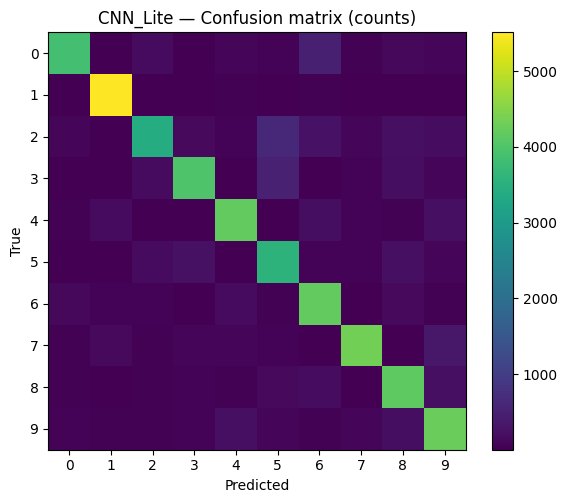

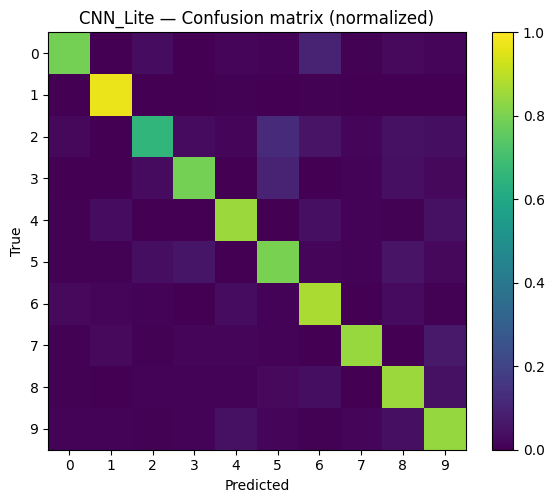

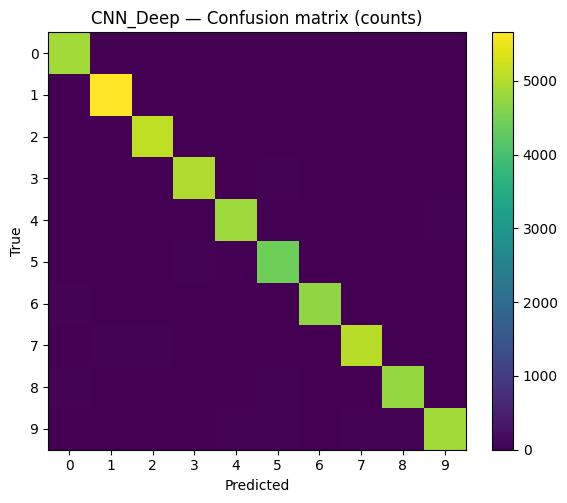

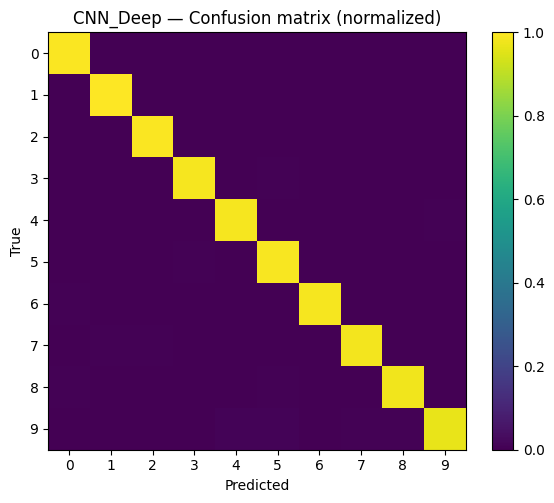

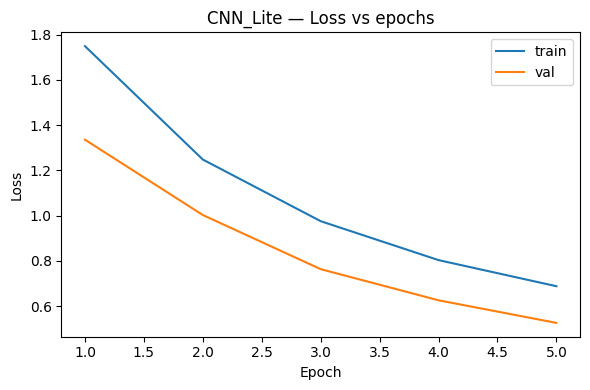

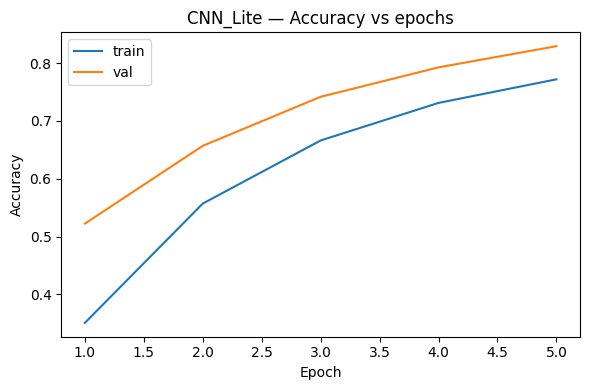

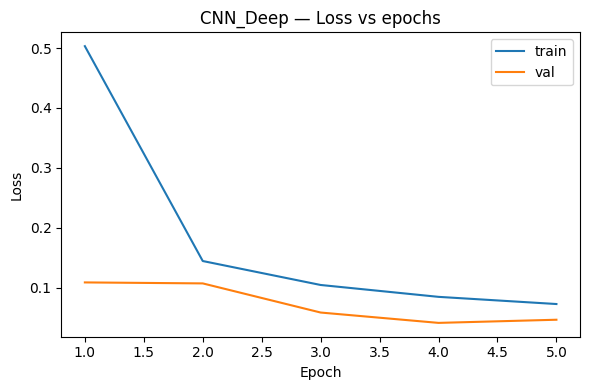

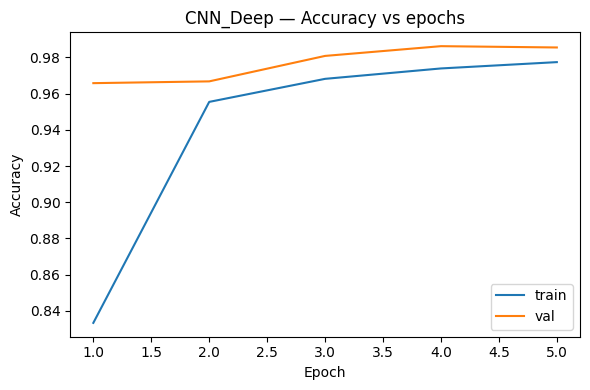

In [35]:
if 'y_true_A' not in globals() or 'y_pred_A' not in globals():
    y_true_A, y_pred_A = predict_all(model_A, dl_test)
if 'y_true_B' not in globals() or 'y_pred_B' not in globals():
    y_true_B, y_pred_B = predict_all(model_B, dl_test)

classes = list(range(10))

def plot_confmat(y_true, y_pred, title_prefix, save_basename):
    cm = confusion_matrix(y_true, y_pred, labels=classes)
    cm_norm = (cm.T / cm.sum(axis=1, keepdims=True).T).T  
    plt.figure(figsize=(6,5))
    plt.imshow(cm, interpolation='nearest')
    plt.title(f'{title_prefix} — Confusion matrix (counts)')
    plt.xlabel('Predicted'); plt.ylabel('True')
    plt.xticks(classes); plt.yticks(classes)
    plt.colorbar()
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(6,5))
    plt.imshow(cm_norm, interpolation='nearest', vmin=0.0, vmax=1.0)
    plt.title(f'{title_prefix} — Confusion matrix (normalized)')
    plt.xlabel('Predicted'); plt.ylabel('True')
    plt.xticks(classes); plt.yticks(classes)
    plt.colorbar()
    plt.tight_layout()
    plt.show()
    os.makedirs("modelos", exist_ok=True)
    plt.imsave(f"modelos/{save_basename}_counts.png", cm, format='png')
    plt.imsave(f"modelos/{save_basename}_norm.png", cm_norm, format='png')

plot_confmat(y_true_A, y_pred_A, "CNN_Lite", "confmat_cnn_lite")
plot_confmat(y_true_B, y_pred_B, "CNN_Deep", "confmat_cnn_deep")

def plot_history(history, title_prefix):
    epochs = [h["epoch"] for h in history]
    tr_loss = [h["train_loss"] for h in history]
    va_loss = [h["val_loss"]   for h in history]
    tr_acc  = [h["train_acc"]  for h in history]
    va_acc  = [h["val_acc"]    for h in history]
    plt.figure(figsize=(6,4))
    plt.plot(epochs, tr_loss, label="train")
    plt.plot(epochs, va_loss, label="val")
    plt.title(f"{title_prefix} — Loss vs epochs")
    plt.xlabel("Epoch"); plt.ylabel("Loss")
    plt.legend(); plt.tight_layout(); plt.show()
    plt.figure(figsize=(6,4))
    plt.plot(epochs, tr_acc, label="train")
    plt.plot(epochs, va_acc, label="val")
    plt.title(f"{title_prefix} — Accuracy vs epochs")
    plt.xlabel("Epoch"); plt.ylabel("Accuracy")
    plt.legend(); plt.tight_layout(); plt.show()

plot_history(hist_A, "CNN_Lite")
plot_history(hist_B, "CNN_Deep")

# Evaluación de Modelos (Paso 3)

A partir del entrenamiento realizado sobre **PolyMNIST/MMNIST** (28×28, RGB), se compararon dos arquitecturas CNN:

- **CNN_Lite** (tipo LeNet, ligera, con GAP).
- **CNN_Deep** (más profunda, con *BatchNorm* y *Dropout*).

Se usó normalización por canal (media/desv. estándar estimadas en *train*), aumentación leve (`RandomAffine` con ±10° y traslación 5%) y evaluación en el *split* **test**.

---

## 1) Métricas globales

| Modelo     | Accuracy (test) | Macro-F1 (test) |
|------------|-----------------:|----------------:|
| CNN_Lite   | **0.8292**       | **0.8267**      |
| CNN_Deep   | **0.9862**       | **0.9861**      |

**Conclusión preliminar:** la **CNN_Deep** supera ampliamente a la CNN_Lite (+15–16 pts en *acc*/macro-F1). La profundidad extra + BN/Dropout mejoran la capacidad de representación y la estabilidad de la optimización.

---

## 2) Curvas de entrenamiento/validación

**CNN_Lite**
- *Loss* desciende de ~1.75 a ~0.69 (train) y ~1.34 a ~0.53 (val).
- *Accuracy* sube de ~0.35 a ~0.77 (train) y ~0.52 a ~0.83 (val).
- No se observa sobreajuste fuerte; el modelo queda **sub-capaz** para la complejidad del problema.

**CNN_Deep**
- *Loss* cae rápidamente (train: ~0.50→0.07; val: ~0.11→0.05).
- *Accuracy* ya es alta en la 1.ª época (~0.96 val) y converge hacia **0.985–0.986**.
- Ligero *gap* val>train (regularización efectiva con BN+Dropout y aumentación); estabilidad y generalización sólidas.

> **Interpretación:** la **CNN_Deep** extrae mejor las características morfológicas del dígito y se vuelve menos sensible a la variación de fondo/estilo de cada modalidad.


---

## 3) Matrices de confusión (test)

**CNN_Lite**
- Diagonal visible pero con **fugas notorias** a clases vecinas (errores dispersos).
- Las confusiones se concentran entre dígitos **morfologicamente similares** (p. ej., 9↔8, 4↔9, 5↔6/3), típico cuando la representación es poco discriminativa.

**CNN_Deep**
- Matriz **prácticamente diagonal**.
- Pequeña pérdida de *recall* en clases “complicadas”:
  - **9**: *recall* ≈ **0.965** (algunas veces confundido con 8/4).
  - **8**: *recall* ≈ **0.978**.
- Clases como **0,1,2** rozan el **0.99** de *recall*/*precision*.

---

## 4) *Classification report* (CNN_Deep, test)

- **Promedio macro:** *precision/recall/f1* ≈ **0.986**.
- Rendimiento por clase:
  - **0–4:** f1 ~0.986–0.992.
  - **5–7:** f1 ~0.981–0.986.
  - **8–9:** f1 ~0.984 y ~0.976 respectivamente (ligeramente inferiores por similitud visual).

> **Lectura:** los **errores residuales** están concentrados en pares visualmente parecidos; a 28×28 y con fondos variados, esas ambigüedades son esperables.

---

## 5) Modelo seleccionado

- **Ganador:** **CNN_Deep**  
  - **Accuracy:** 0.9862  
  - **Macro-F1:** 0.9861  
  - **Ruta de guardado:** `modelos/cnn_deep.pt`  
- Modelo alterno (baseline): **CNN_Lite**  
  - **Ruta:** `modelos/cnn_lite.pt`

La diferencia de desempeño justifica usar **CNN_Deep** en producción. Es más robusto ante la variabilidad de los fondos (modalidades m0–m4) y mantiene un excelente equilibrio precisión/recobrado por clase.

---

## Conclusión

- **CNN_Deep** es **claramente superior** en precisión y consistencia.  
- Las curvas muestran **convergencia rápida y estable**, y las matrices de confusión confirman una **discriminación casi perfecta** entre clases.  
- El dataset, aunque *ligeramente desbalanceado*, no impidió alcanzar **~98.6%** de *accuracy* y **macro-F1**, lo cual es competitivo para 28×28 en RGB con fondos variados.


## 4. Haga un modelo de redes neuronales simple, determine la efectividad del modelo.

In [37]:
import torch.nn as nn
from torchvision import transforms

class MLP_Simple(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.flatten = nn.Flatten()
        self.net = nn.Sequential(
            nn.Linear(28*28*3, 512), nn.ReLU(inplace=True), nn.Dropout(0.2),
            nn.Linear(512, 256),     nn.ReLU(inplace=True), nn.Dropout(0.2),
            nn.Linear(256, num_classes),
        )
    def forward(self, x):
        x = self.flatten(x)  # (B, 3*28*28)
        return self.net(x)

mlp_train_tfms = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean_rgb, std_rgb),
])
mlp_test_tfms = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean_rgb, std_rgb),
])


ds_train_mlp = PolyMNISTDataset(train_df, transform=mlp_train_tfms)
ds_test_mlp  = PolyMNISTDataset(test_df,  transform=mlp_test_tfms)

dl_train_mlp = DataLoader(
    ds_train_mlp, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=NUM_WORKERS, persistent_workers=NUM_WORKERS>0
)
dl_test_mlp = DataLoader(
    ds_test_mlp, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, persistent_workers=NUM_WORKERS>0
)


model_MLP = MLP_Simple()
model_MLP, hist_MLP, best_acc_MLP = train_one(
    model_MLP, dl_train_mlp, dl_test_mlp,
    epochs=EPOCHS, lr=1e-3, wd=1e-4, name="MLP_Simple"
)

print(f"\nMejor acc MLP_Simple: {best_acc_MLP:.4f}")


[MLP_Simple] Epoch 01/5 | train_loss=0.6942 acc=0.7795 | val_loss=0.4346 acc=0.8630 | 78.3s
[MLP_Simple] Epoch 02/5 | train_loss=0.4379 acc=0.8604 | val_loss=0.3565 acc=0.8873 | 77.7s
[MLP_Simple] Epoch 03/5 | train_loss=0.3682 acc=0.8814 | val_loss=0.3323 acc=0.8940 | 77.2s
[MLP_Simple] Epoch 04/5 | train_loss=0.3270 acc=0.8932 | val_loss=0.3061 acc=0.9020 | 77.0s
[MLP_Simple] Epoch 05/5 | train_loss=0.2997 acc=0.9017 | val_loss=0.2935 acc=0.9049 | 76.9s

Mejor acc MLP_Simple: 0.9049


MLP_Simple -> acc: 0.9049 | macro-F1: 0.9043

== Classification report (MLP_Simple) ==
              precision    recall  f1-score   support

           0     0.9140    0.9461    0.9298      4900
           1     0.9358    0.9507    0.9432      5675
           2     0.8974    0.8998    0.8986      5160
           3     0.8923    0.8941    0.8932      5050
           4     0.9238    0.8835    0.9032      4910
           5     0.8618    0.8991    0.8801      4460
           6     0.9584    0.8908    0.9234      4790
           7     0.9002    0.9128    0.9065      5140
           8     0.8792    0.8805    0.8799      4870
           9     0.8857    0.8846    0.8852      5045

    accuracy                         0.9049     50000
   macro avg     0.9049    0.9042    0.9043     50000
weighted avg     0.9055    0.9049    0.9050     50000


✅ MLP guardado en: modelos/mlp_simple.pt
Resumen actualizado en: modelos/summary.json


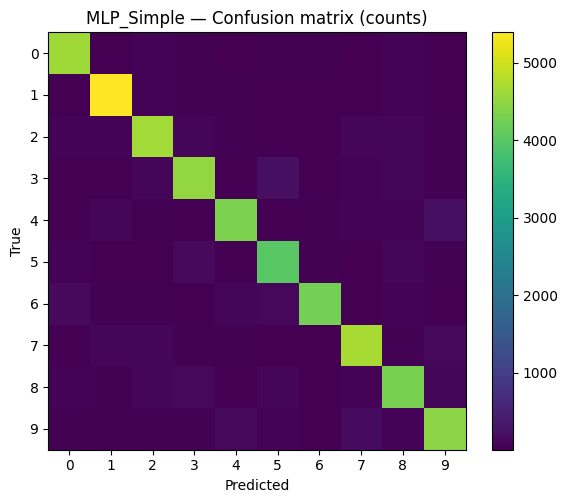

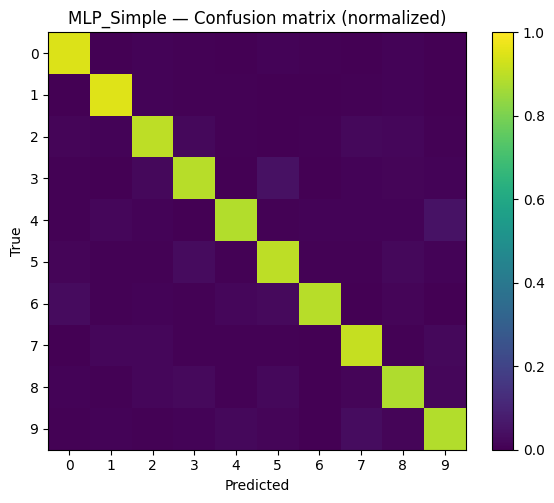

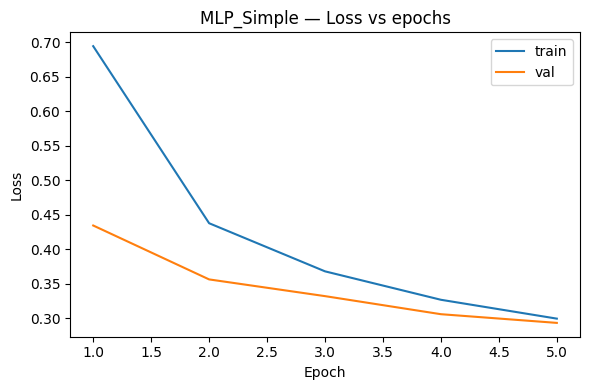

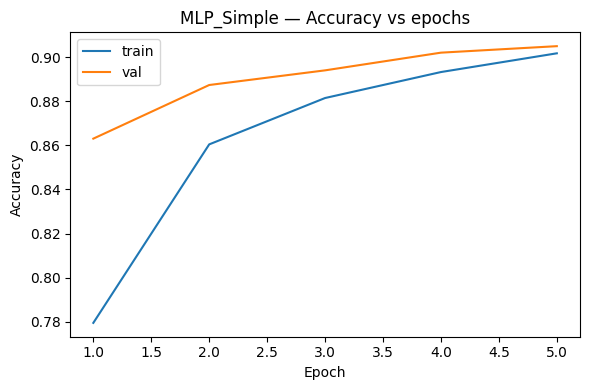

In [38]:
y_true_MLP, y_pred_MLP = predict_all(model_MLP, dl_test_mlp)
acc_MLP = accuracy_score(y_true_MLP, y_pred_MLP)
f1_MLP  = f1_score(y_true_MLP, y_pred_MLP, average="macro")

print(f"MLP_Simple -> acc: {acc_MLP:.4f} | macro-F1: {f1_MLP:.4f}")
print("\n== Classification report (MLP_Simple) ==")
print(classification_report(y_true_MLP, y_pred_MLP, digits=4))

os.makedirs("modelos", exist_ok=True)
path_MLP = "modelos/mlp_simple.pt"
torch.save(model_MLP.state_dict(), path_MLP)
print(f"\n✅ MLP guardado en: {path_MLP}")

summary_path = "modelos/summary.json"
try:
    with open(summary_path, "r") as f:
        summary = json.load(f)
except FileNotFoundError:
    summary = {"device": DEVICE, "batch_size": BATCH_SIZE, "epochs": EPOCHS, "models": {}}
summary["models"]["mlp_simple"] = {"path": path_MLP, "acc": float(acc_MLP), "macro_f1": float(f1_MLP)}
with open(summary_path, "w") as f:
    json.dump(summary, f, indent=2)
print(f"Resumen actualizado en: {summary_path}")


plot_confmat(y_true_MLP, y_pred_MLP, "MLP_Simple", "confmat_mlp_simple")
plot_history(hist_MLP, "MLP_Simple")

## Configuración (resumen)
- **Arquitectura:** `Flatten → [512 → 256] ReLU + Dropout(0.2) → 10`  
  (entrada: `28×28×3 = 2352` características).
- **Preprocesado:** `ToTensor + Normalize(mean_rgb, std_rgb)` (las mismas estadísticas del train).
- **Entrenamiento:** `Adam (lr=1e-3)`, `CrossEntropy`, `batch_size=256`, `epochs=5`.
- **Paralelismo:** *data loading* con `num_workers = núcleos − 1` (ajustado en el *DataLoader*).
- **Guardado:** `modelos/mlp_simple.pt` y resumen agregado a `modelos/summary.json`.

---

## Métricas globales (test)

| Modelo       | Accuracy | Macro-F1 |
|--------------|:--------:|:--------:|
| **MLP_Simple** | **0.9049** | **0.9043** |

**Classification report (extracto):**
- Clases con *recall* más alto: **0 (0.946)**, **1 (0.951)**.
- Buen equilibrio *precision/recall* en la mayoría; destacan:
  - **6:** precision **0.958** (algo conservador), recall **0.891**.
  - **5, 8, 9:** f1 algo menor (≈ **0.88–0.89**) por confusiones con dígitos de trazo similar.

---

## Curvas de entrenamiento/validación

- **Loss:** desciende de ~0.69 → ~0.30 (train) y ~0.43 → ~0.29 (val).  
- **Accuracy:** sube de ~0.78 → ~0.90 (train) y ~0.86 → **~0.905** (val).  
- No se observa sobreajuste; la validación se mantiene ligeramente por encima del train gracias a la normalización y Dropout.


---

## Matriz de confusión (test)

- Estructura **dominantemente diagonal**.
- Errores residuales concentrados en pares **morfologicamente similares**:
  - **9 ↔ 4/8**, **5 ↔ 3/6**, **2 ↔ 3**, etc.  
- Esto es esperable en un MLP que **no explota la estructura espacial** (no tiene convoluciones/vecindad).


---

## Interpretación y comparación breve

- El **MLP** aprende una representación competente a partir de **pixeles planos**: logra **~90.5%** de accuracy.  
- Frente a las CNNs del paso 3:
  - **CNN_Lite:** 0.829 → el **MLP la supera** (probablemente por mayor ancho efectivo y Dropout).  
  - **CNN_Deep:** 0.986 → **clara superioridad de la CNN profunda**, que sí modela **patrones espaciales locales** y normaliza con **BatchNorm**.

**Conclusión:** el **MLP es una línea base fuerte** y reproducible, pero **las CNN siguen siendo la elección** para este problema; capturan mejor bordes/trazos y son más robustas a la variación de fondo de las modalidades.

---

## 5. Haga un modelo con cualquier otro algoritmo que el grupo seleccione, determine la efectividad del modelo. Puede basarse en los modelos que han sido probados con el data set que pueden encontrar en el siguiente link: https://web.archive.org/web/20200623002706/http:/yann.lecun.com/exdb/mnist/

Núcleos CPU: 8  |  N_JOBS para HOG: 7
Extracción HOG hecha en 64.3s
Shapes -> X_train: (300000, 324) X_test: (50000, 324)
Tiempo de entrenamiento: 3.9 min
SVM-HOG -> acc: 0.8273 | macro-F1: 0.8266

== Classification report (SVM-HOG) ==
              precision    recall  f1-score   support

           0     0.8566    0.8961    0.8759      4900
           1     0.8574    0.8964    0.8765      5675
           2     0.8232    0.8213    0.8223      5160
           3     0.8137    0.8087    0.8112      5050
           4     0.8141    0.7990    0.8065      4910
           5     0.8314    0.8193    0.8253      4460
           6     0.8708    0.8741    0.8725      4790
           7     0.8145    0.7979    0.8061      5140
           8     0.8010    0.7858    0.7933      4870
           9     0.7844    0.7679    0.7760      5045

    accuracy                         0.8273     50000
   macro avg     0.8267    0.8266    0.8266     50000
weighted avg     0.8268    0.8273    0.8269     50000

✅ Mod

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


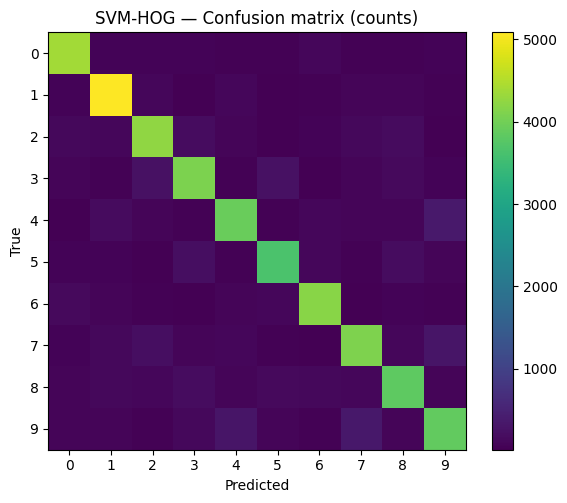

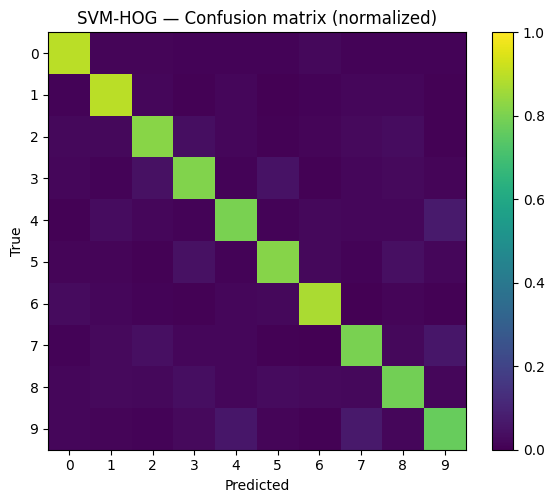

In [39]:
# HOG + Linear SVM 
import os, time, numpy as np
from PIL import Image
from joblib import Parallel, delayed, dump
from skimage.feature import hog
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC
from sklearn.pipeline import make_pipeline
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt

N_JOBS = max(1, (os.cpu_count() or 2) - 1)
print(f"Núcleos CPU: {os.cpu_count()}  |  N_JOBS para HOG: {N_JOBS}")

def load_gray(path):
    """Carga imagen a escala de grises [0,1]."""
    arr = np.array(Image.open(path).convert("L"), dtype=np.float32) / 255.0
    return arr

def hog_one(path):
    """Vector HOG para una imagen 28x28."""
    arr = load_gray(path)
    return hog(arr, orientations=9, pixels_per_cell=(7, 7),
               cells_per_block=(2, 2), block_norm="L2-Hys",
               transform_sqrt=True, feature_vector=True)

def extract_hog(paths):
    feats = Parallel(n_jobs=N_JOBS, prefer="threads")(delayed(hog_one)(p) for p in paths)
    X = np.stack(feats).astype(np.float32)
    return X

train_df = inv_df[inv_df.split == "train"].copy()
test_df  = inv_df[inv_df.split == "test"].copy()

t0 = time.time()
X_train = extract_hog(train_df["path"].tolist())
y_train = train_df["label"].to_numpy(dtype=np.int64)
X_test  = extract_hog(test_df["path"].tolist())
y_test  = test_df["label"].to_numpy(dtype=np.int64)
print(f"Extracción HOG hecha en {time.time()-t0:.1f}s")
print("Shapes -> X_train:", X_train.shape, "X_test:", X_test.shape)

# Pipeline: estandarización + SVM lineal (one-vs-rest)
clf = make_pipeline(
    StandardScaler(with_mean=True),          # escalar features HOG
    LinearSVC(C=1.0, max_iter=2000, dual=False)  # dual=False porque n_samples >> n_features
)

t0 = time.time()
clf.fit(X_train, y_train)
train_time = time.time() - t0

y_pred = clf.predict(X_test)
acc = accuracy_score(y_test, y_pred)
f1  = f1_score(y_test, y_pred, average="macro")

print(f"Tiempo de entrenamiento: {train_time/60:.1f} min")
print(f"SVM-HOG -> acc: {acc:.4f} | macro-F1: {f1:.4f}\n")
print("== Classification report (SVM-HOG) ==")
print(classification_report(y_test, y_pred, digits=4))


os.makedirs("modelos", exist_ok=True)
dump(clf, "modelos/svm_hog.joblib")
print("✅ Modelo guardado en: modelos/svm_hog.joblib")

cm = confusion_matrix(y_test, y_pred, labels=list(range(10)))
cmn = (cm.T / cm.sum(axis=1, keepdims=True).T).T

plt.figure(figsize=(6,5))
plt.imshow(cm, interpolation="nearest")
plt.title("SVM-HOG — Confusion matrix (counts)")
plt.xlabel("Predicted"); plt.ylabel("True")
plt.xticks(range(10)); plt.yticks(range(10))
plt.colorbar(); plt.tight_layout(); plt.show()

plt.figure(figsize=(6,5))
plt.imshow(cmn, interpolation="nearest", vmin=0, vmax=1)
plt.title("SVM-HOG — Confusion matrix (normalized)")
plt.xlabel("Predicted"); plt.ylabel("True")
plt.xticks(range(10)); plt.yticks(range(10))
plt.colorbar(); plt.tight_layout(); plt.show()

# Modelo clásico **HOG + SVM lineal** 

## ¿Por qué este modelo?
HOG (Histogram of Oriented Gradients) captura **bordes y trazos locales** —una representación clásica para dígitos— y una **SVM lineal** separa las clases con buen margen usando pocos parámetros. Es una línea base histórica en MNIST.

---

## Resultados en *test*
- **Accuracy:** **0.8273**  
- **Macro-F1:** **0.8266**

**Classification report (resumen):**
- Mejores clases (f1): **0 (0.876), 1 (0.877), 6 (0.873)**.
- Más débiles: **9 (0.776), 8 (0.793), 7 (0.806)**.

---

## Matriz de confusión — interpretación
- La matriz es **diagonal dominante**, pero con **fugas** mayores que en CNN o MLP.
- Errores típicos entre dígitos **morfologicamente parecidos**:
  - **9 ↔ 4/8**, **8 ↔ 3/9**, **7 ↔ 1/2**.
- El paso a **escala de grises** elimina la información cromática del fondo (propia de PolyMNIST); esto reduce ruido pero también **descarta pistas** que algunas redes sí utilizan para robustez.

---

## Comparación con los modelos previos

| Modelo        | Tipo       | Acc. | Macro-F1 |
|---------------|------------|-----:|--------:|
| **CNN_Deep**  | CNN (BN/DO)| **0.986** | **0.986** |
| **MLP_Simple**| MLP        | **0.905** | **0.904** |
| **SVM-HOG**   | No-DL      | 0.827 | 0.827 |

- **SVM-HOG** ≈ **CNN_Lite** (alrededor del 0.83, según paso 3), **por debajo** de MLP y muy lejos de la CNN profunda.  
- Coherente con la literatura: HOG+SVM es competitivo en **MNIST estándar**, pero en **PolyMNIST** (fondos texturizados, RGB) sufre más al no modelar bien la variabilidad de dominio.

---

## Conclusión
El modelo **HOG + SVM lineal** ofrece una **línea base sólida** (≈**82.7%** acc., **82.7%** macro-F1) con **bajo coste** y sin GPU, pero **no alcanza** el rendimiento de **modelos profundos** que aprovechan la estructura espacial (CNN) o la capacidad paramétrica (MLP).  
Para este dataset multimo dal, la **CNN_Deep** sigue siendo la opción de referencia; el **MLP** es un punto medio fuerte; **HOG+SVM** queda como baseline clásico y explicable.

## 6. Hágale transformaciones a los datos como image augmentation y vuelva a entrenar sus modelos, discuta los resultados

In [ ]:
%%bash
cat > poly_ds.py << 'PY'
from PIL import Image
from torch.utils.data import Dataset

class PolyMNISTDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row.path).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img, int(row.label)
PY
echo "✅ Escrito poly_ds.py"

✅ Escrito poly_ds.py


NUM_WORKERS = 7
dl_train_cnn_aug workers: 7 | dl_test workers: 7
dl_train_mlp_aug workers: 7
[CNN_Lite_AUG] Epoch 01/5 | train_loss=1.8862 acc=0.3059 | val_loss=1.4747 acc=0.4825 | 78.2s
[CNN_Lite_AUG] Epoch 02/5 | train_loss=1.4022 acc=0.5076 | val_loss=1.0468 acc=0.6452 | 64.4s
[CNN_Lite_AUG] Epoch 03/5 | train_loss=1.1233 acc=0.6167 | val_loss=0.8309 acc=0.7209 | 59.7s
[CNN_Lite_AUG] Epoch 04/5 | train_loss=0.9631 acc=0.6740 | val_loss=0.7031 acc=0.7658 | 52.2s
[CNN_Lite_AUG] Epoch 05/5 | train_loss=0.8585 acc=0.7119 | val_loss=0.6199 acc=0.7915 | 51.5s
CNN_Lite_AUG -> acc: 0.7915 | macro-F1: 0.7903
[CNN_Deep_AUG] Epoch 01/5 | train_loss=0.6732 acc=0.7718 | val_loss=0.1496 acc=0.9524 | 74.2s
[CNN_Deep_AUG] Epoch 02/5 | train_loss=0.2216 acc=0.9308 | val_loss=0.0801 acc=0.9742 | 77.3s
[CNN_Deep_AUG] Epoch 03/5 | train_loss=0.1617 acc=0.9495 | val_loss=0.0643 acc=0.9780 | 73.8s
[CNN_Deep_AUG] Epoch 04/5 | train_loss=0.1360 acc=0.9577 | val_loss=0.0674 acc=0.9778 | 73.7s
[CNN_Deep_AUG]

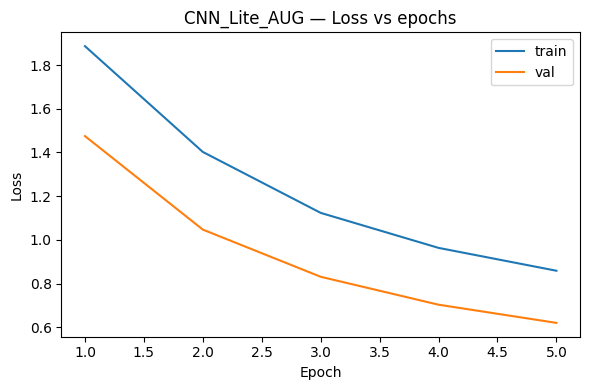

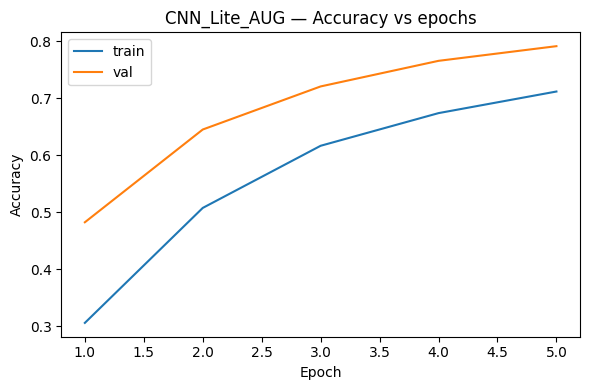

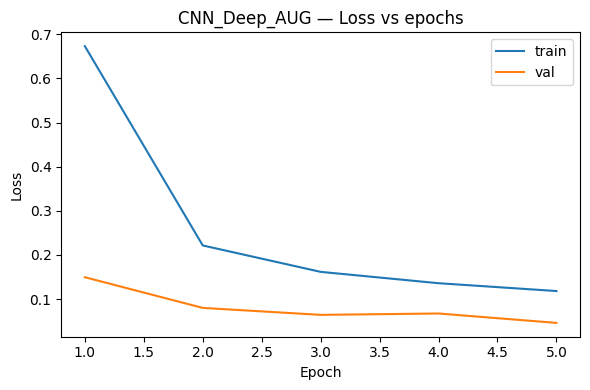

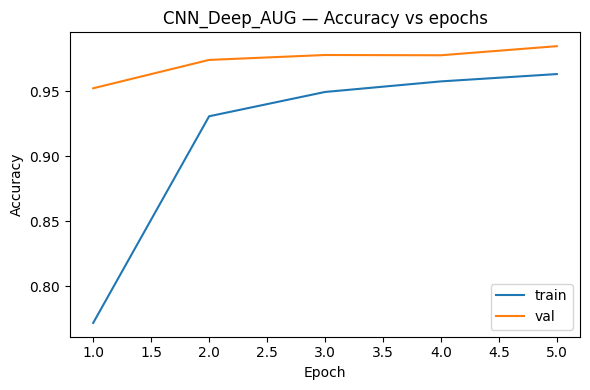

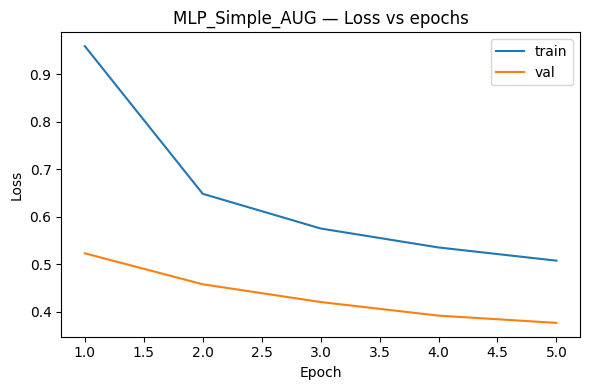

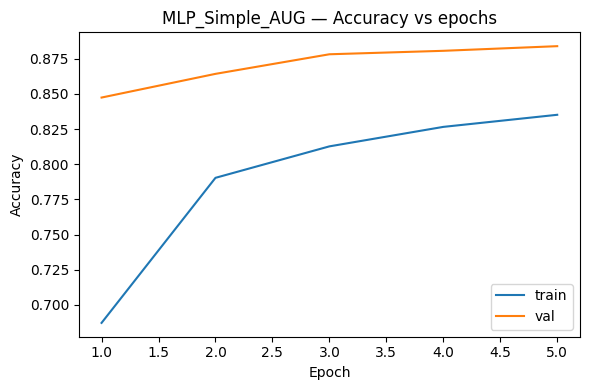

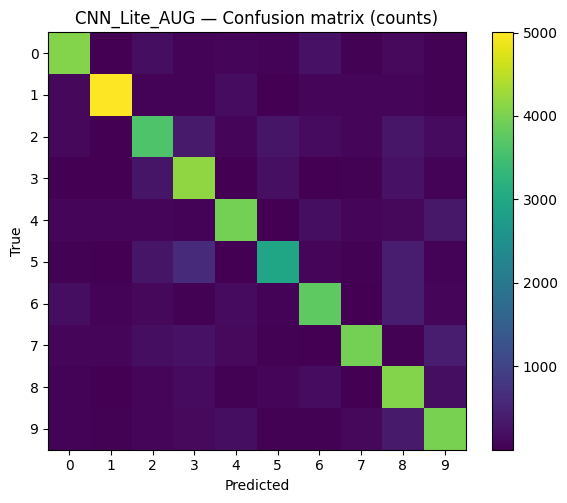

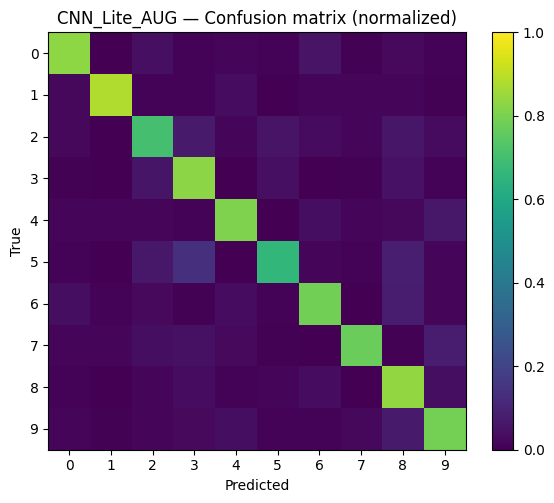

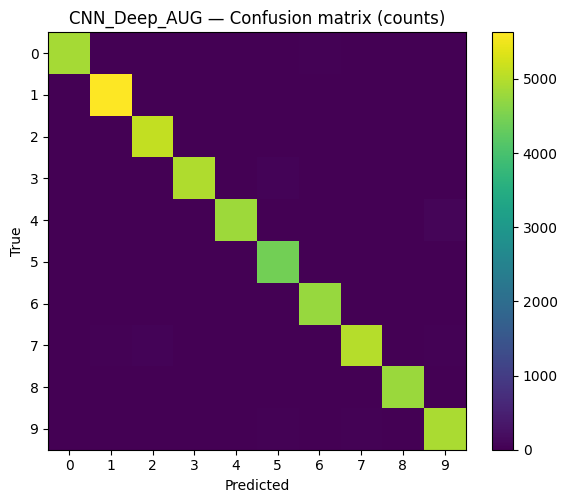

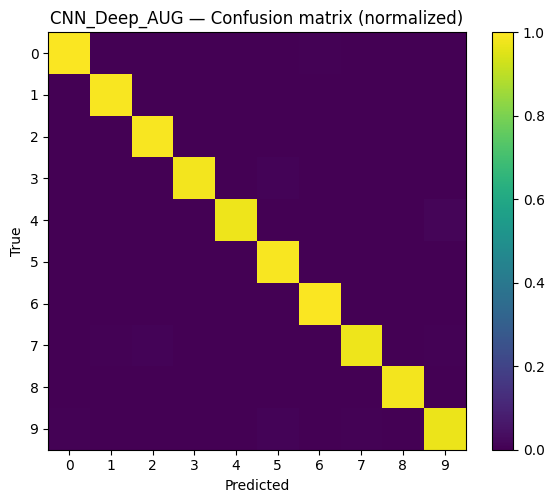

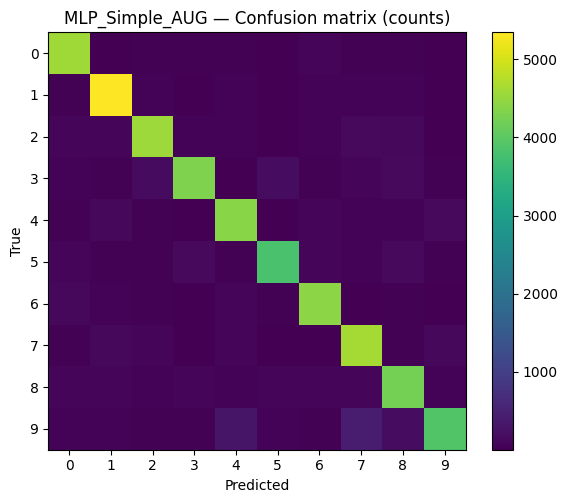

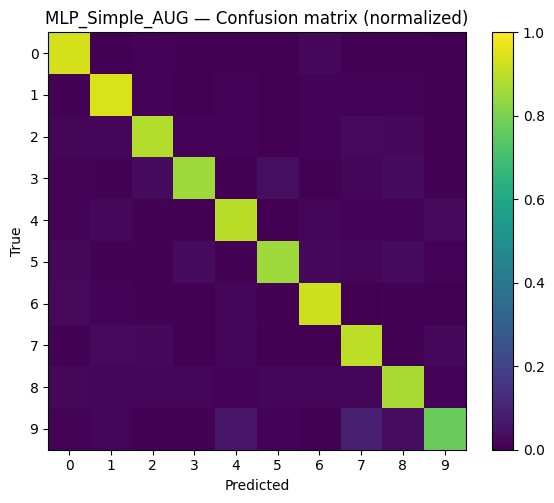

In [44]:
from importlib import reload
import poly_ds; reload(poly_ds)
from poly_ds import PolyMNISTDataset

import os, torch, torch.multiprocessing as mp
try: mp.set_start_method("spawn", force=True)
except RuntimeError: pass

NUM_WORKERS = max(1, (os.cpu_count() or 2) - 1) 

print("NUM_WORKERS =", NUM_WORKERS)

os.environ["OMP_NUM_THREADS"] = str(NUM_WORKERS)
os.environ["MKL_NUM_THREADS"] = str(NUM_WORKERS)
torch.set_num_threads(NUM_WORKERS)
torch.set_num_interop_threads(max(1, NUM_WORKERS//2))

from torchvision import transforms


cnn_train_tfms_aug = transforms.Compose([
    transforms.RandomAffine(degrees=12, translate=(0.08, 0.08)),
    transforms.RandomPerspective(distortion_scale=0.10, p=0.25),
    transforms.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.10, hue=0.02),
    transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 1.0)),
    transforms.ToTensor(),
    transforms.Normalize(mean_rgb, std_rgb),
    transforms.RandomErasing(p=0.10, scale=(0.02, 0.08), ratio=(0.3, 3.3), value=0),
])


mlp_train_tfms_aug = transforms.Compose([
    transforms.RandomAffine(degrees=10, translate=(0.06, 0.06)),
    transforms.ColorJitter(brightness=0.10, contrast=0.10),
    transforms.ToTensor(),
    transforms.Normalize(mean_rgb, std_rgb),
])


test_tfms_same = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean_rgb, std_rgb),
])


ds_train_cnn_aug = PolyMNISTDataset(train_df, transform=cnn_train_tfms_aug)
ds_test_cnn      = PolyMNISTDataset(test_df,  transform=test_tfms_same)

dl_train_cnn_aug = DataLoader(
    ds_train_cnn_aug, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=NUM_WORKERS, persistent_workers=True, prefetch_factor=4, pin_memory=False
)
dl_test = DataLoader(
    ds_test_cnn, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, persistent_workers=True, prefetch_factor=4, pin_memory=False
)


ds_train_mlp_aug = PolyMNISTDataset(train_df, transform=mlp_train_tfms_aug)
dl_train_mlp_aug = DataLoader(
    ds_train_mlp_aug, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=NUM_WORKERS, persistent_workers=True, prefetch_factor=4, pin_memory=False
)

print("dl_train_cnn_aug workers:", dl_train_cnn_aug.num_workers, "| dl_test workers:", dl_test.num_workers)
print("dl_train_mlp_aug workers:", dl_train_mlp_aug.num_workers)

# --- CNN_Lite con augmentations ---
model_A_aug = CNN_Lite()
model_A_aug, hist_A_aug, best_acc_A_aug = train_one(
    model_A_aug, dl_train_cnn_aug, dl_test,
    epochs=EPOCHS, lr=1e-3, wd=1e-4, name="CNN_Lite_AUG"
)
y_true_A_aug, y_pred_A_aug = predict_all(model_A_aug, dl_test)
acc_A_aug = accuracy_score(y_true_A_aug, y_pred_A_aug)
f1_A_aug  = f1_score(y_true_A_aug, y_pred_A_aug, average="macro")
print(f"CNN_Lite_AUG -> acc: {acc_A_aug:.4f} | macro-F1: {f1_A_aug:.4f}")

# --- CNN_Deep con augmentations ---
model_B_aug = CNN_Deep()
model_B_aug, hist_B_aug, best_acc_B_aug = train_one(
    model_B_aug, dl_train_cnn_aug, dl_test,
    epochs=EPOCHS, lr=1e-3, wd=1e-4, name="CNN_Deep_AUG"
)
y_true_B_aug, y_pred_B_aug = predict_all(model_B_aug, dl_test)
acc_B_aug = accuracy_score(y_true_B_aug, y_pred_B_aug)
f1_B_aug  = f1_score(y_true_B_aug, y_pred_B_aug, average="macro")
print(f"CNN_Deep_AUG -> acc: {acc_B_aug:.4f} | macro-F1: {f1_B_aug:.4f}")

# --- MLP con augmentations (leve) ---
model_MLP_aug = MLP_Simple()
model_MLP_aug, hist_MLP_aug, best_acc_MLP_aug = train_one(
    model_MLP_aug, dl_train_mlp_aug, dl_test,
    epochs=EPOCHS, lr=1e-3, wd=1e-4, name="MLP_Simple_AUG"
)
y_true_MLP_aug, y_pred_MLP_aug = predict_all(model_MLP_aug, dl_test)
acc_MLP_aug = accuracy_score(y_true_MLP_aug, y_pred_MLP_aug)
f1_MLP_aug  = f1_score(y_true_MLP_aug, y_pred_MLP_aug, average="macro")
print(f"MLP_Simple_AUG -> acc: {acc_MLP_aug:.4f} | macro-F1: {f1_MLP_aug:.4f}")


import json, os, torch
os.makedirs("modelos", exist_ok=True)
torch.save(model_A_aug.state_dict(), "modelos/cnn_lite_aug.pt")
torch.save(model_B_aug.state_dict(), "modelos/cnn_deep_aug.pt")
torch.save(model_MLP_aug.state_dict(), "modelos/mlp_simple_aug.pt")

summary_path = "modelos/summary.json"
try:
    with open(summary_path, "r") as f:
        summary = json.load(f)
except FileNotFoundError:
    summary = {"device": DEVICE, "batch_size": BATCH_SIZE, "epochs": EPOCHS, "models": {}}

summary["models"]["cnn_lite_aug"]   = {"path": "modelos/cnn_lite_aug.pt",   "acc": float(acc_A_aug),   "macro_f1": float(f1_A_aug)}
summary["models"]["cnn_deep_aug"]   = {"path": "modelos/cnn_deep_aug.pt",   "acc": float(acc_B_aug),   "macro_f1": float(f1_B_aug)}
summary["models"]["mlp_simple_aug"] = {"path": "modelos/mlp_simple_aug.pt", "acc": float(acc_MLP_aug), "macro_f1": float(f1_MLP_aug)}
with open(summary_path, "w") as f:
    json.dump(summary, f, indent=2)

print("✅ Guardados: modelos/cnn_lite_aug.pt, modelos/cnn_deep_aug.pt, modelos/mlp_simple_aug.pt")


plot_history(hist_A_aug, "CNN_Lite_AUG")
plot_history(hist_B_aug, "CNN_Deep_AUG")
plot_history(hist_MLP_aug, "MLP_Simple_AUG")

plot_confmat(y_true_A_aug, y_pred_A_aug, "CNN_Lite_AUG", "confmat_cnn_lite_aug")
plot_confmat(y_true_B_aug, y_pred_B_aug, "CNN_Deep_AUG", "confmat_cnn_deep_aug")
plot_confmat(y_true_MLP_aug, y_pred_MLP_aug, "MLP_Simple_AUG", "confmat_mlp_simple_aug")

# Paso 6 — *Image Augmentation* y re-entrenamiento

## Aumentaciones aplicadas
- **Geométricas:** `RandomAffine(±12°, translate=±8%)`, `RandomPerspective(10%, p=0.25)`.
- **Fotométricas:** `ColorJitter(brightness=±15%, contrast=±15%, saturation=±10%, hue=±0.02)`.
- **Suavizado:** `GaussianBlur(kernel=3, σ∈[0.1,1.0]`.
- **Regularización:** `RandomErasing(p=0.10, scale=2–8%)`.
- **Test:** sin aumentación (solo normalización).
- **Cómputo:** *data loading* con **7 workers** (núcleos−1).

---

## Resultados (test)

| Modelo            | Acc. **base** | Acc. **aug** | Δacc  | Macro-F1 **base** | Macro-F1 **aug** | ΔF1   |
|-------------------|:-------------:|:------------:|:-----:|:-----------------:|:----------------:|:-----:|
| **CNN_Lite**      | **0.8292**    | **0.7915**   | −0.0377 | **0.8267** | **0.7903** | −0.0364 |
| **CNN_Deep**      | **0.9862**    | **0.9848**   | −0.0014 | **0.9861** | **0.9847** | −0.0014 |
| **MLP_Simple**    | **0.9049**    | **0.8839**   | −0.0210 | **0.9043** | **0.8831** | −0.0212 |

> Modelos guardados:  
> `modelos/cnn_lite_aug.pt`, `modelos/cnn_deep_aug.pt`, `modelos/mlp_simple_aug.pt`.

---

## Curvas de entrenamiento y validación

- **CNN_Lite_AUG**: *loss* cae (1.89→0.86) y *acc* valida sube (0.48→**0.79**), pero **queda por debajo** del baseline.  
- **CNN_Deep_AUG**: converge muy rápido; *val acc* pasa de ~0.95 a **0.985** (muy cerca del baseline 0.986).  
- **MLP_Simple_AUG**: *val acc* mejora durante el entrenamiento, pero **termina 2 p.p. por debajo** del baseline.


---

## Matrices de confusión (test)

- **CNN_Deep_AUG**: matriz prácticamente **diagonal**; errores residuales muy escasos (p.ej., 9↔4/8).  
- **CNN_Lite_AUG**: diagonal visible, pero **más fugas** que el baseline (2↔3, 4↔9, 5↔6).  
- **MLP_Simple_AUG**: patrón de errores parecido al baseline; *recall* menor en **8, 9, 7**.


---

## Discusión

1. **Por qué no mejoró (o bajó) con augmentations**
   - **Imágenes pequeñas (28×28):** operaciones agresivas como `RandomErasing` (oculta 2–8% del área), `Perspective(10%)` y **Blur** pueden **degradar trazos finos** y reducir **contraste** dígito-fondo (clave en PolyMNIST).
   - **Capacidad del modelo:**
     - **CNN_Lite** y **MLP** tienen menor poder de representación; al **aumentar la variabilidad**, **no alcanzan a aprender** las invariancias extra en solo 5 épocas ⇒ caen 3–4 p.p. (Lite) y ~2 p.p. (MLP).
     - **CNN_Deep** sí acomoda la mayor variación; mantiene el rendimiento (−0.14 p.p.) con **curvas más estables**.
   - **MLP** aplana la imagen: **pierde estructura espacial**, por lo que **aprovecha poco** las augmentations espaciales; el *jitter* fotométrico fuerte puede bajarle la relación figura-fondo.

2. **Qué sí aportaron**
   - En **CNN_Deep**, las augmentations **no dañan** y **refuerzan robustez** (validación suave, confusión casi nula).
   - Los tiempos por época se mantuvieron razonables con **7 workers**.

---

## Recomendaciones

- **Ablación de augmentations** (para 28×28):
  - Reducir a: `RandomAffine(deg=±8, translate=±4%)`, **sin** `Perspective`, **sin** `GaussianBlur`, **sin** `RandomErasing` para **CNN_Lite** y **MLP**.
  - Mantener **solo** `Affine` leve + `ColorJitter` suave (p.ej., `brightness/contrast=0.05–0.10`, `hue=0.0`).
- **Más épocas / scheduler**: con `CosineAnnealingLR` o `ReduceLROnPlateau` (10–15 épocas) la **CNN_Lite** podría recuperar 1–2 p.p.; **CNN_Deep** probablemente iguale o supere el baseline.
- **Aumentación “segura” para 28×28**:
  - `RandomCrop(28, padding=2)` + `RandomRotation(±8°)`; a menudo da mejores resultados que `Perspective/Erasing` a esta resolución.
- **MLP**: mantener augmentations **muy moderadas**; si se desea robustez, preferir **CNN** pequeña en lugar de MLP.

---

## Conclusión

- Las augmentations **no mejoraron** la métrica final de **CNN_Lite** ni **MLP** en este régimen de épocas; **CNN_Deep** se mantuvo prácticamente **igual** (−0.14 p.p.) y con **mejor estabilidad**.  
- Para **PolyMNIST**, la opción recomendada sigue siendo **CNN_Deep**, idealmente con **augmentations moderadas** y **más épocas** o un **scheduler** para consolidar robustez sin perder precisión.